In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from cnmf import cNMF

# ====== 必改 ======
PATIENT_KEY = "patients"     # 改成 adata.obs 里的患者列名（如 patient_id / orig.ident）
COUNT_LAYER = "counts_RNA"       # 你说是 count
OUTDIR = Path("./cnmf_npc1") # 输出根目录

# ====== cNMF 参数（稳健起步）======
K_RANGE = list(range(2, 11))   # K 扫描范围
N_ITER  = 50                 # >=50 更稳
NUM_HVG = 2000
SEED    = 14
DENSITY_THRESHOLD = 0.1

# ====== 最小过滤（避免 0/极差细胞拖垮 NMF）======
MIN_COUNTS_PER_CELL = 50
MIN_CELLS_PER_GENE  = 10
MIN_CELLS_PER_PATIENT = 100

# 目录：只两层，不套娃
PDIR = OUTDIR / "per_patient"
SDIR = OUTDIR / "summary"
PDIR.mkdir(parents=True, exist_ok=True)
SDIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad('malignant_patients.h5ad')
adata

AnnData object with n_obs × n_vars = 10435 × 44066
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'patients', 'RNA_snn_res.0.3', 'seurat_clusters', 'doublet_score', 'Contamination', 'RNA_snn_res.1'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts_RNA'

In [2]:
# ====== 过滤不需要的基因 ======
toremove = [f"AC{i}" for i in range(0,10)] + [f"AL{i}" for i in range(0,10)] + ["LINC", "MT-", "ENSG"]
adata = adata[:, ~adata.var_names.str.startswith(tuple(toremove))].copy()
print("Filtered genes:", adata.n_vars)

Filtered genes: 28058


In [3]:
# ====== 工具函数 ======
def counts_to_X(adata, layer="counts_RNA"):
    ad = adata.copy()
    ad.X = ad.layers[layer]
    if sp.issparse(ad.X):
        ad.X = ad.X.astype(np.float32)
    else:
        ad.X = np.asarray(ad.X, dtype=np.float32)
    return ad

def prefilter(ad):
    ad = ad.copy()
    sc.pp.filter_cells(ad, min_counts=MIN_COUNTS_PER_CELL)
    sc.pp.filter_genes(ad, min_cells=MIN_CELLS_PER_GENE)

    if sp.issparse(ad.X):
        cs = np.array(ad.X.sum(axis=1)).ravel()
        gs = np.array(ad.X.sum(axis=0)).ravel()
    else:
        cs = ad.X.sum(axis=1)
        gs = ad.X.sum(axis=0)

    return ad[cs > 0, gs > 0].copy()

def save_top_genes(top_genes, out_csv: Path):
    if isinstance(top_genes, pd.DataFrame):
        df = top_genes
    elif isinstance(top_genes, dict):
        df = pd.DataFrame({str(k): pd.Series(v) for k, v in top_genes.items()})
    elif isinstance(top_genes, list) and len(top_genes) > 0 and isinstance(top_genes[0], (list, tuple, pd.Index)):
        df = pd.DataFrame({f"program_{i}": pd.Series(g) for i, g in enumerate(top_genes)})
    else:
        df = pd.DataFrame({"program_0": pd.Series(top_genes if isinstance(top_genes, list) else [top_genes])})
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)

In [4]:
# ====== 转换 counts 层 ======
adata_counts = counts_to_X(adata, layer=COUNT_LAYER)

In [ ]:
# ====== Per-patient cNMF ======
patients = sorted(adata_counts.obs[PATIENT_KEY].astype(str).unique())
print("n_patients =", len(patients))
print(patients)

for pid in patients:
    ad_p = adata_counts[adata_counts.obs[PATIENT_KEY].astype(str) == pid].copy()
    if ad_p.n_obs < MIN_CELLS_PER_PATIENT:
        print(f"[SKIP] {pid}: {ad_p.n_obs} cells")
        continue

    ad_p = prefilter(ad_p)
    if ad_p.n_obs < MIN_CELLS_PER_PATIENT or ad_p.n_vars < 500:
        print(f"[SKIP] {pid}: after filter cells={ad_p.n_obs}, genes={ad_p.n_vars}")
        continue

    out_p = PDIR / pid
    out_p.mkdir(parents=True, exist_ok=True)

    counts_fn = out_p / f"{pid}.counts.h5ad"
    ad_p.write(counts_fn)

    cn = cNMF(output_dir=str(PDIR), name=pid)
    cn.prepare(counts_fn=str(counts_fn), components=K_RANGE, n_iter=N_ITER, seed=SEED, num_highvar_genes=NUM_HVG)
    cn.factorize(worker_i=0, total_workers=1)
    cn.combine()
    cn.k_selection_plot(close_fig=False)
    print(f"[DONE] {pid} -> {PDIR/pid}/{pid}.k_selection.png")

n_patients = 25
['NPC10', 'NPC11', 'NPC12', 'NPC13', 'NPC14', 'NPC16', 'NPC18', 'NPC19', 'NPC2', 'NPC20', 'NPC21', 'NPC22', 'NPC26', 'NPC27', 'NPC28', 'NPC29', 'NPC3', 'NPC30', 'NPC31', 'NPC32', 'NPC33', 'NPC34', 'NPC4', 'NPC5', 'NPC7']
[Worker 0]. Starting task 0.
[Worker 0]. Starting task 1.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 3.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 5.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 7.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 9.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 11.
[Worker 0]. Starting task 12.
[Worker 0]. Starting task 13.
[Worker 0]. Starting task 14.
[Worker 0]. Starting task 15.
[Worker 0]. Starting task 16.
[Worker 0]. Starting task 17.
[Worker 0]. Starting task 18.
[Worker 0]. Starting task 19.
[Worker 0]. Starting task 20.
[Worker 0]. Starting task 21.
[Worker 0]. Starting task 22.
[Worker 0]. Starting task 23.
[Worker 0]. Starting task 24.
[Worker 0]. Starting ta

[Worker 0]. Starting task 262.
[Worker 0]. Starting task 263.
[Worker 0]. Starting task 264.
[Worker 0]. Starting task 265.
[Worker 0]. Starting task 266.
[Worker 0]. Starting task 267.
[Worker 0]. Starting task 268.
[Worker 0]. Starting task 269.
[Worker 0]. Starting task 270.
[Worker 0]. Starting task 271.
[Worker 0]. Starting task 272.
[Worker 0]. Starting task 273.
[Worker 0]. Starting task 274.
[Worker 0]. Starting task 275.
[Worker 0]. Starting task 276.
[Worker 0]. Starting task 277.
[Worker 0]. Starting task 278.
[Worker 0]. Starting task 279.
[Worker 0]. Starting task 280.
[Worker 0]. Starting task 281.
[Worker 0]. Starting task 282.
[Worker 0]. Starting task 283.
[Worker 0]. Starting task 284.
[Worker 0]. Starting task 285.
[Worker 0]. Starting task 286.
[Worker 0]. Starting task 287.
[Worker 0]. Starting task 288.
[Worker 0]. Starting task 289.
[Worker 0]. Starting task 290.
[Worker 0]. Starting task 291.
[Worker 0]. Starting task 292.
[Worker 0]. Starting task 293.
[Worker 

[Worker 0]. Starting task 67.
[Worker 0]. Starting task 68.
[Worker 0]. Starting task 69.
[Worker 0]. Starting task 70.
[Worker 0]. Starting task 71.
[Worker 0]. Starting task 72.
[Worker 0]. Starting task 73.
[Worker 0]. Starting task 74.
[Worker 0]. Starting task 75.
[Worker 0]. Starting task 76.
[Worker 0]. Starting task 77.
[Worker 0]. Starting task 78.
[Worker 0]. Starting task 79.
[Worker 0]. Starting task 80.
[Worker 0]. Starting task 81.
[Worker 0]. Starting task 82.
[Worker 0]. Starting task 83.
[Worker 0]. Starting task 84.
[Worker 0]. Starting task 85.
[Worker 0]. Starting task 86.
[Worker 0]. Starting task 87.
[Worker 0]. Starting task 88.
[Worker 0]. Starting task 89.
[Worker 0]. Starting task 90.
[Worker 0]. Starting task 91.
[Worker 0]. Starting task 92.
[Worker 0]. Starting task 93.
[Worker 0]. Starting task 94.
[Worker 0]. Starting task 95.
[Worker 0]. Starting task 96.
[Worker 0]. Starting task 97.
[Worker 0]. Starting task 98.
[Worker 0]. Starting task 99.
[Worker 0]

/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


[Worker 0]. Starting task 301.
[Worker 0]. Starting task 302.


...

[Worker 0]. Starting task 434.
[Worker 0]. Starting task 435.
[Worker 0]. Starting task 436.
[Worker 0]. Starting task 437.
[Worker 0]. Starting task 438.
[Worker 0]. Starting task 439.


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


[Worker 0]. Starting task 440.


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


[Worker 0]. Starting task 441.
[Worker 0]. Starting task 442.
[Worker 0]. Starting task 443.
[Worker 0]. Starting task 444.
[Worker 0]. Starting task 445.
[Worker 0]. Starting task 446.
[Worker 0]. Starting task 447.
[Worker 0]. Starting task 448.
[Worker 0]. Starting task 449.
Combining factorizations for k=2.
Combining factorizations for k=3.
Combining factorizations for k=4.
Combining factorizations for k=5.
Combining factorizations for k=6.
Combining factorizations for k=7.
Combining factorizations for k=8.
Combining factorizations for k=9.
Combining factorizations for k=10.
[DONE] NPC12 -> cnmf_npc1/per_patient/NPC12/NPC12.k_selection.png
[Worker 0]. Starting task 0.
[Worker 0]. Starting task 1.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 3.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 5.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 7.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 9.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 11

Found 13 png files


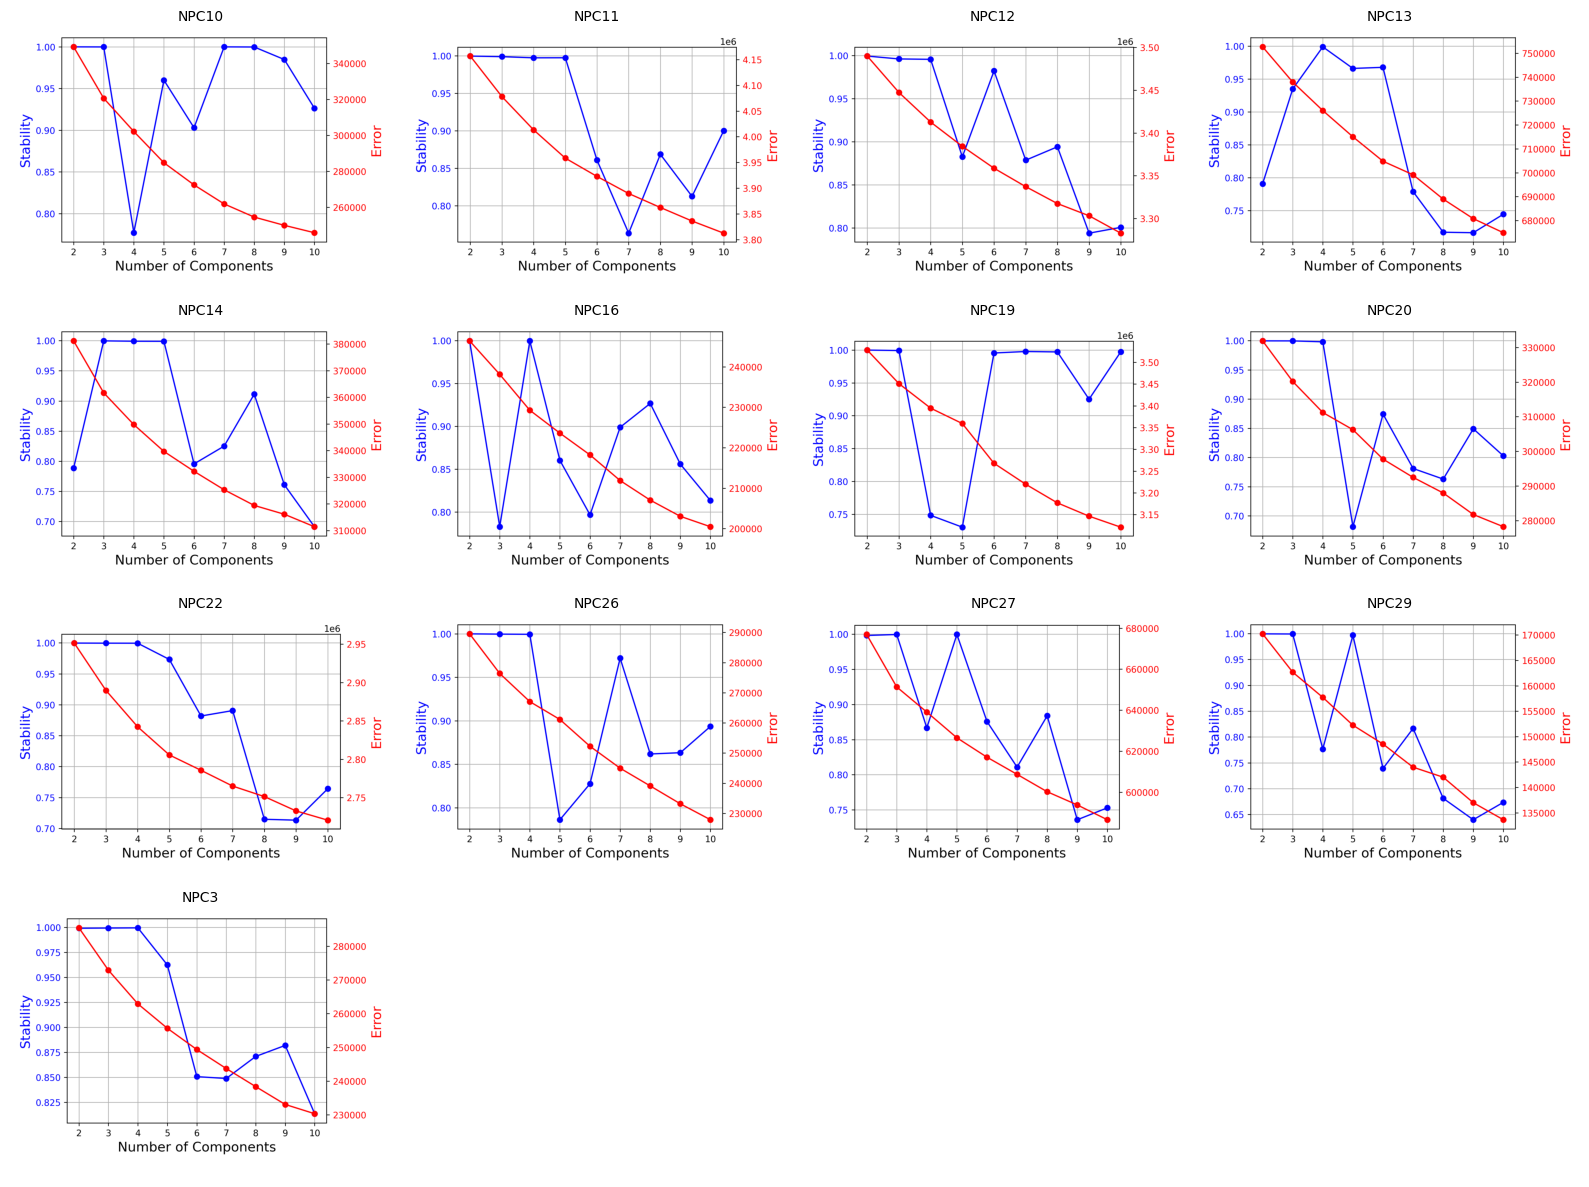

In [7]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 你的输出根目录（按你脚本的 OUTDIR / "per_patient"）
root = Path("./cnmf_npc1/per_patient")

# 找到所有扫K图片
pngs = sorted(root.rglob("*.k_selection.png"))
print("Found", len(pngs), "png files")
pngs[:5]  # 看看前几个路径对不对
ncols = 4  # 每行几张图
n = len(pngs)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten() if n > 1 else [axes]

for ax, p in zip(axes, pngs):
    img = mpimg.imread(p)
    ax.imshow(img)
    ax.set_title(p.parent.name, fontsize=10)  # p.parent.name 通常就是 pid
    ax.axis("off")

# 多余空格子关掉
for ax in axes[len(pngs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [36]:
kfile = SDIR / "K_CHOSEN.csv"
pd.DataFrame({"patient": patients, "chosen_k": ""}).to_csv(kfile, index=False)
print("Fill this file then save:", kfile)


Fill this file then save: cnmf_npc/summary/K_CHOSEN.csv


K_CHOSEN head: [('NPC10', 7), ('NPC11', 5), ('NPC12', 6), ('NPC13', 5), ('NPC14', 5)]


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


[EXPORT] NPC10: K=7


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


[EXPORT] NPC11: K=5


...

[EXPORT] NPC27: K=5


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


[EXPORT] NPC29: K=5


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


[EXPORT] NPC3: K=5


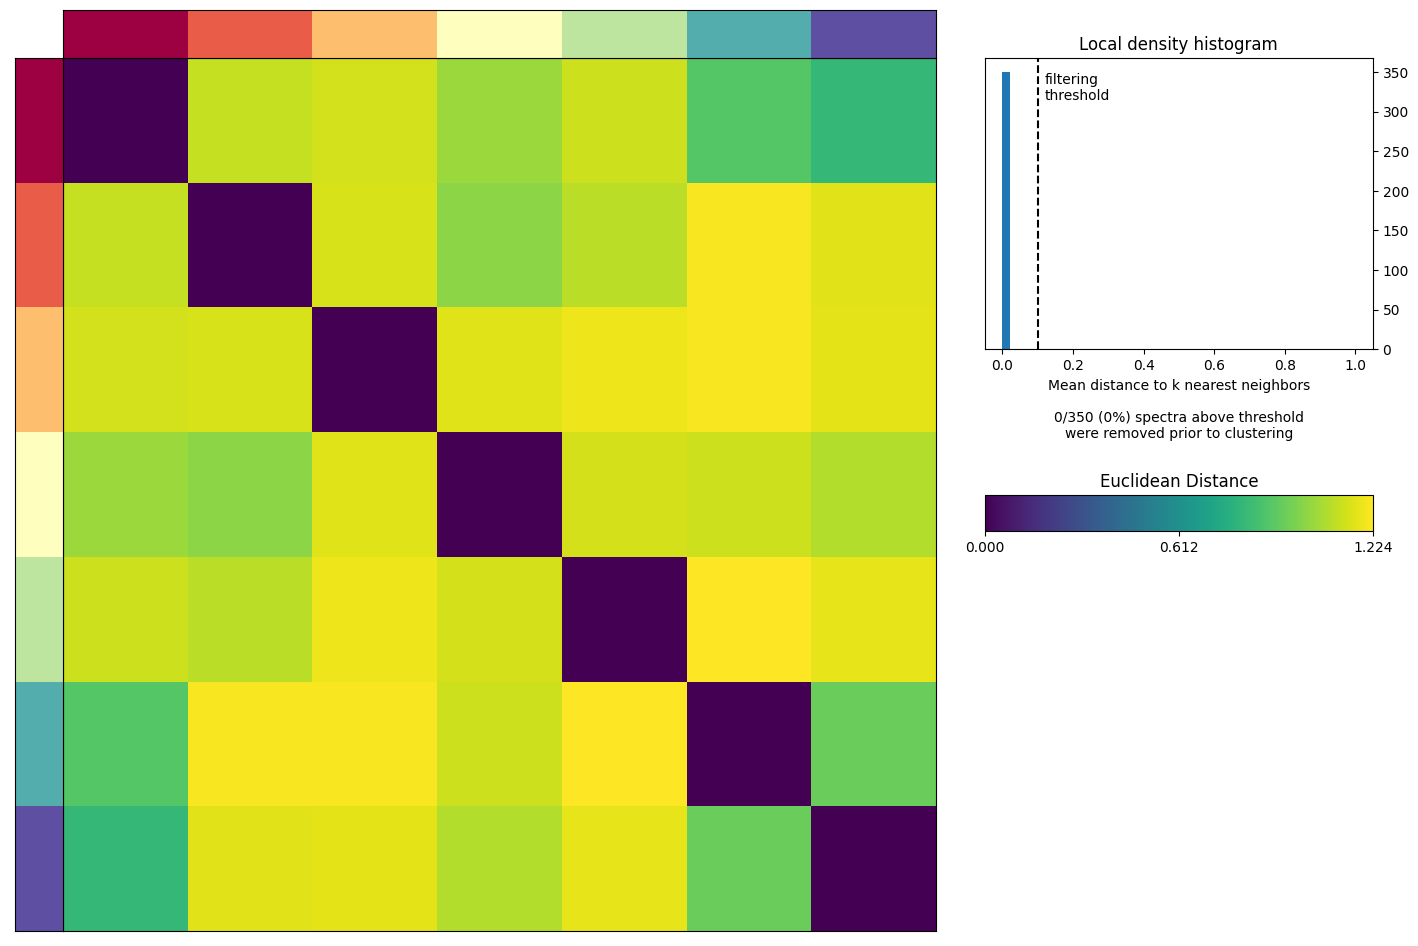

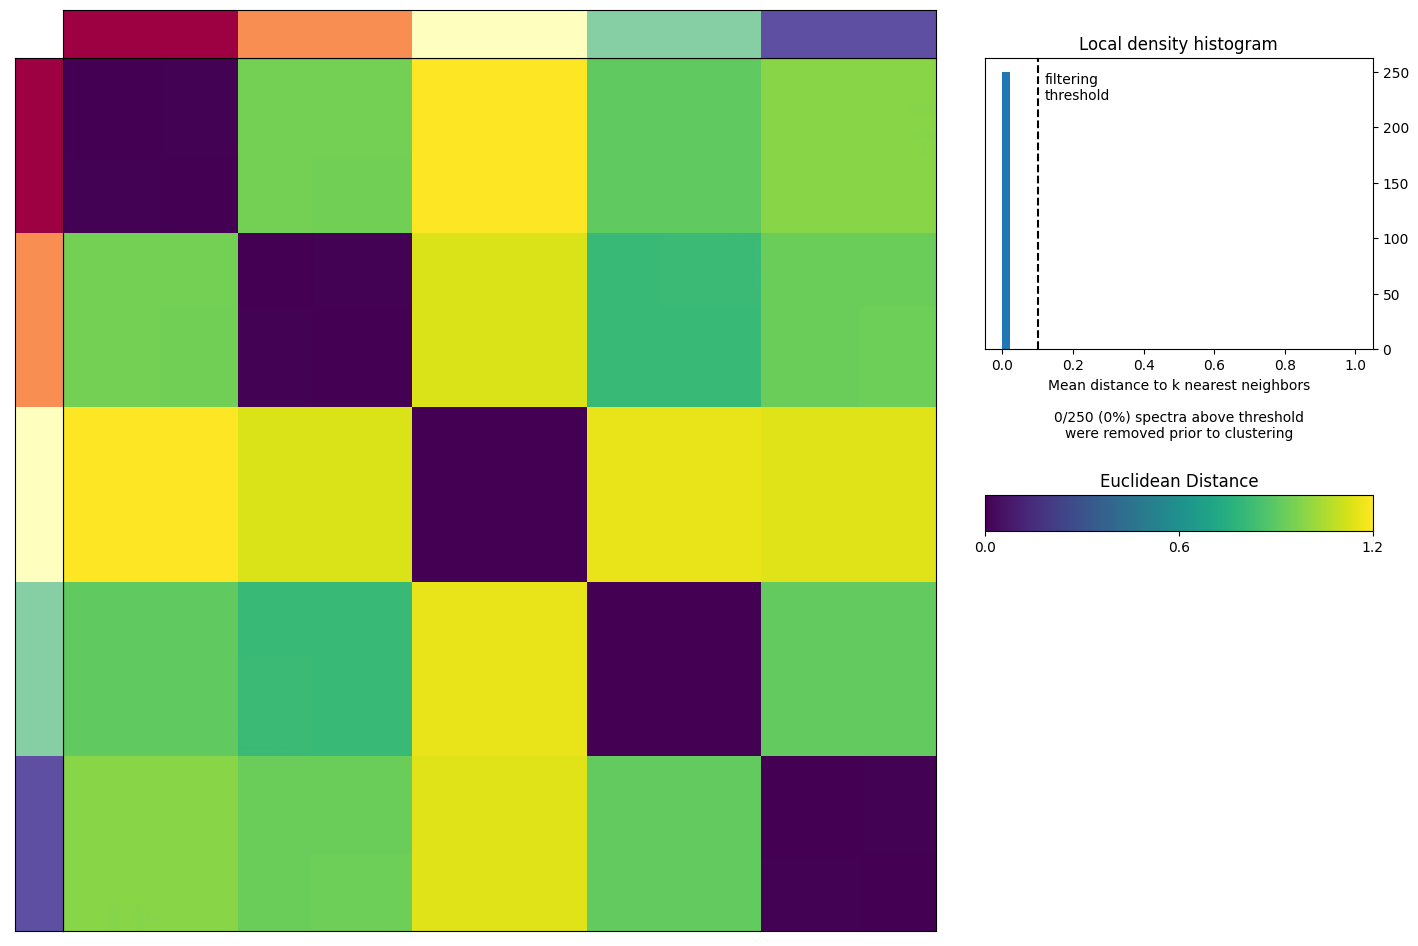

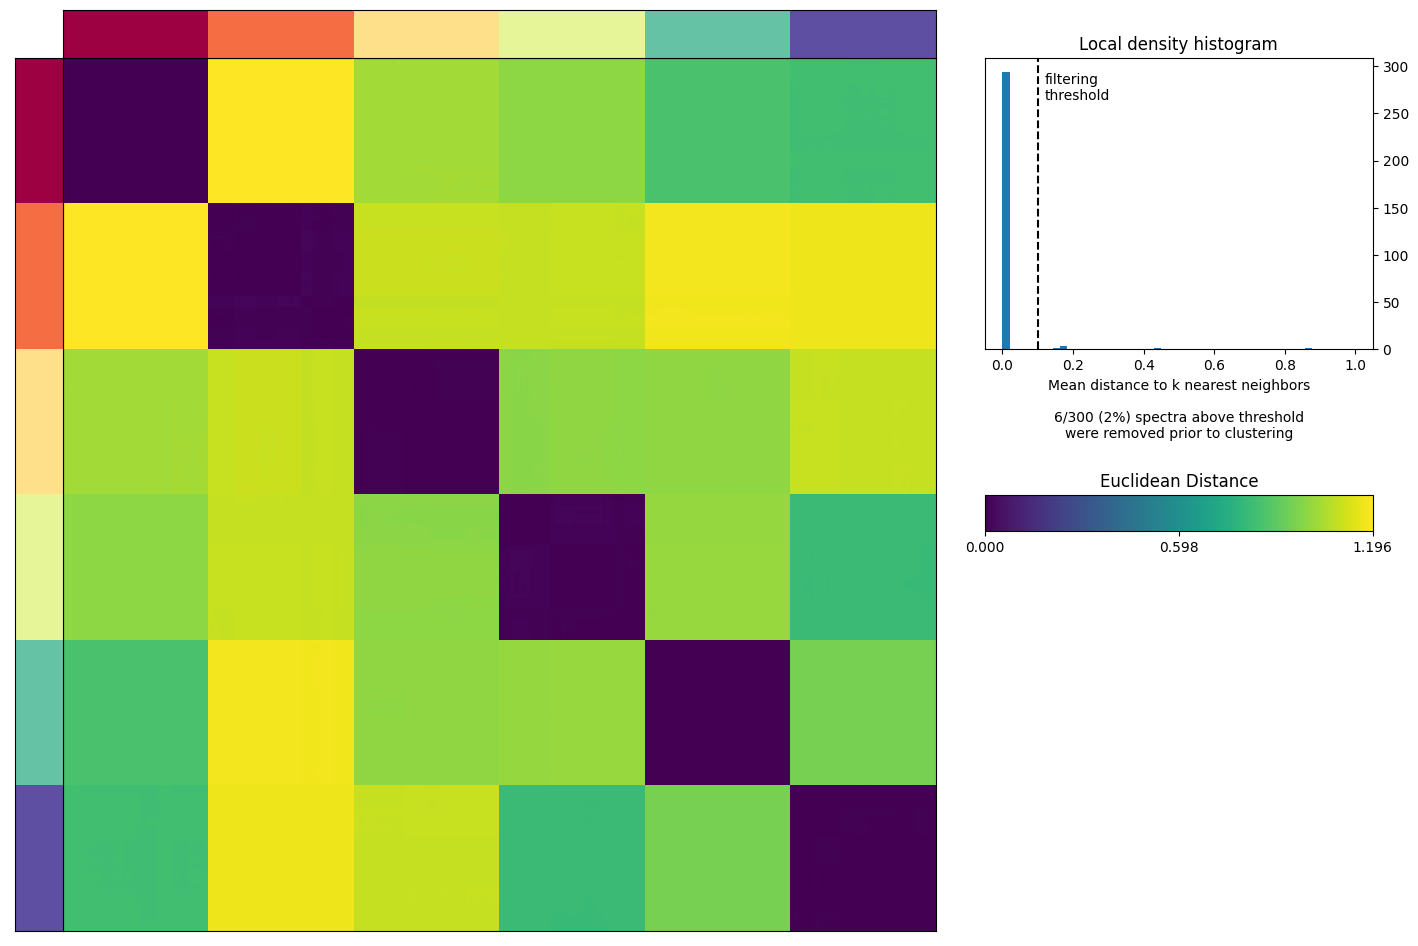

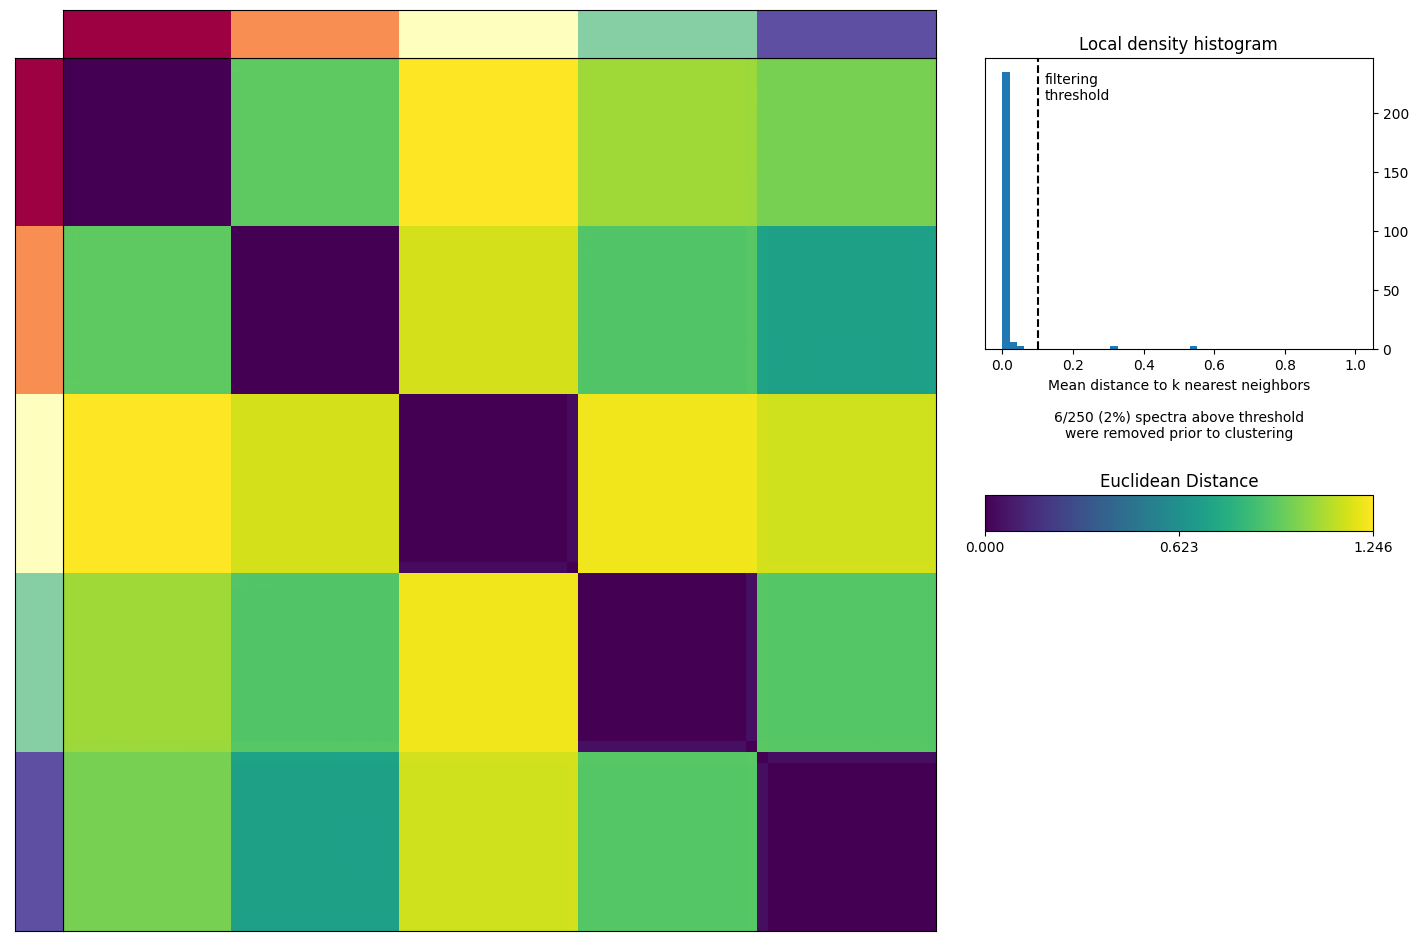

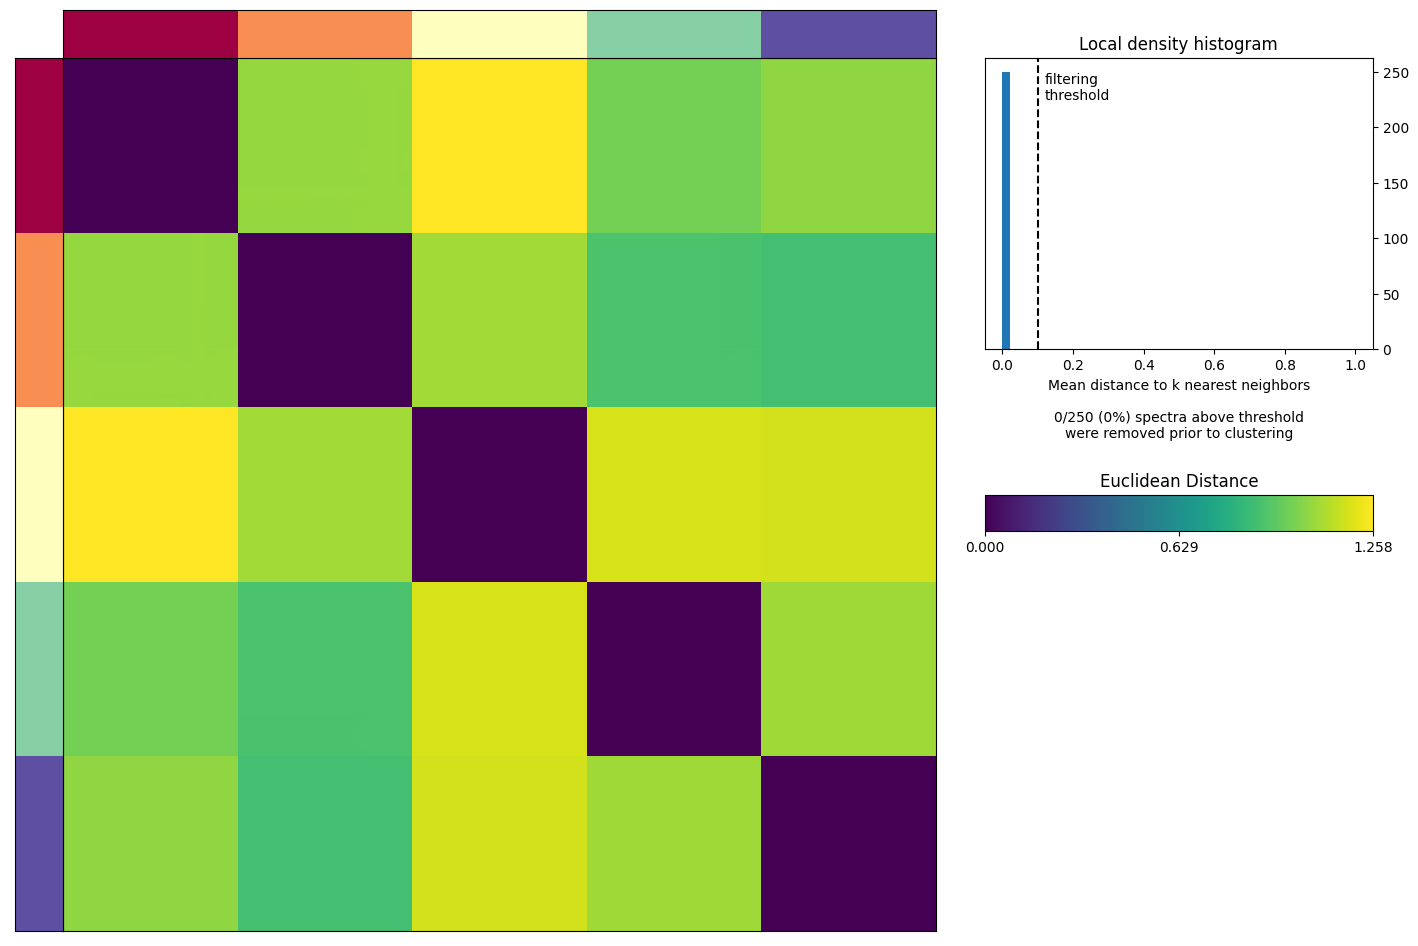

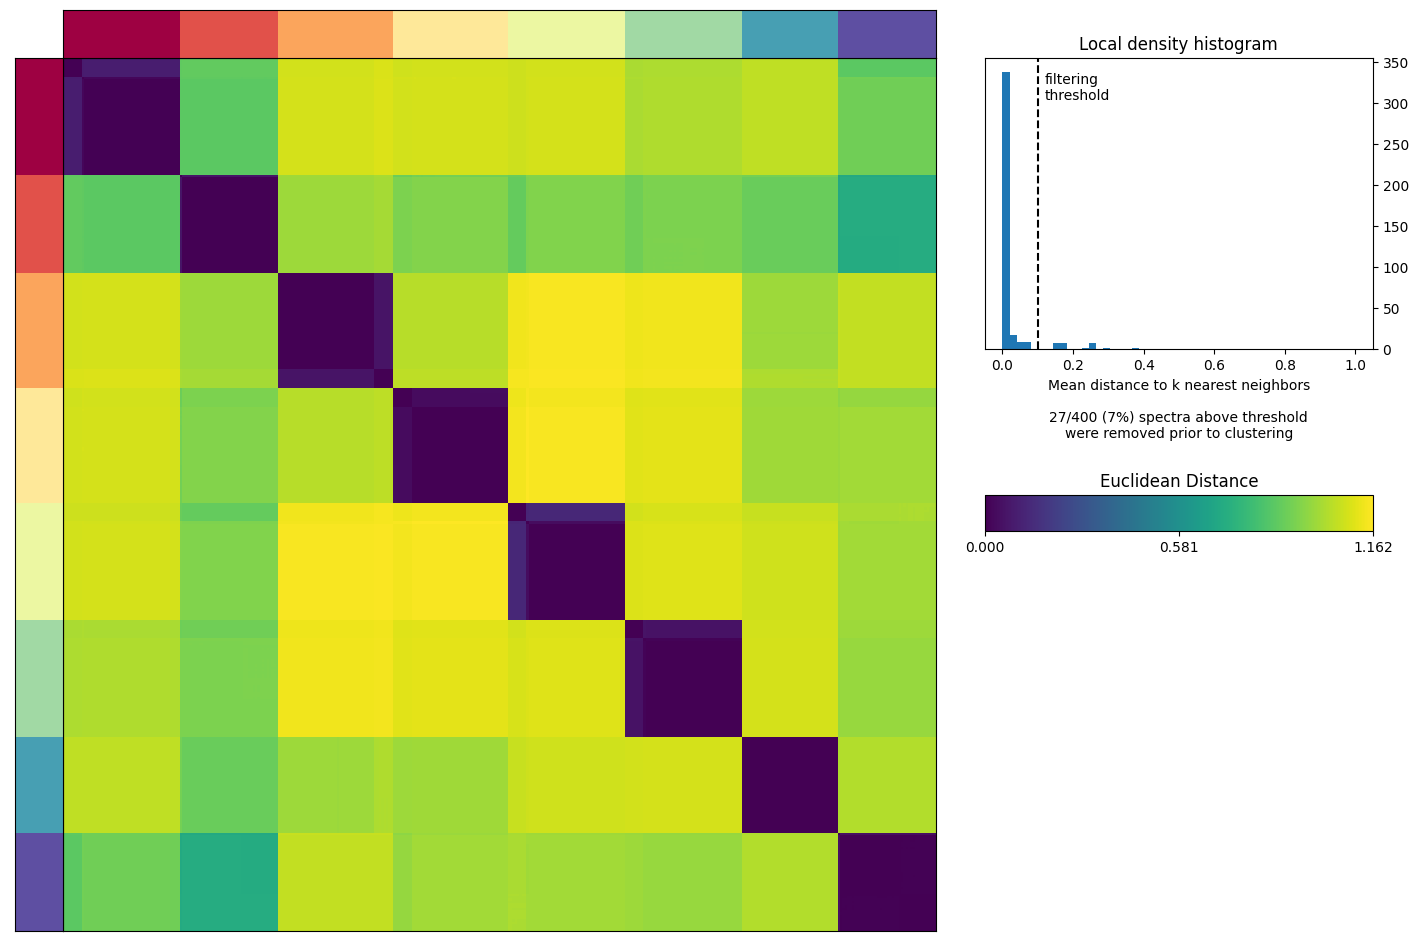

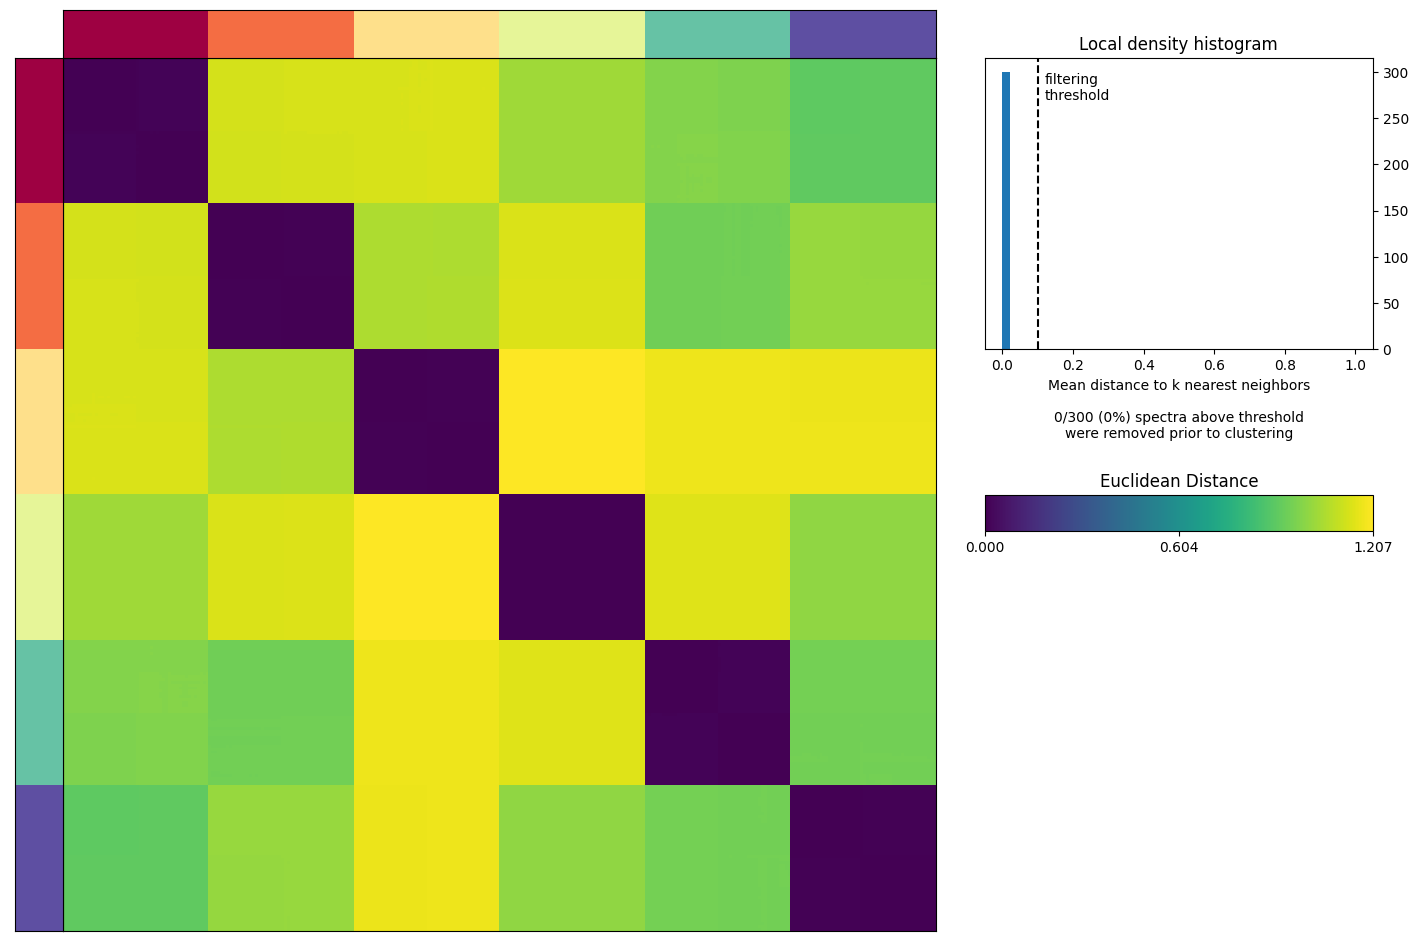

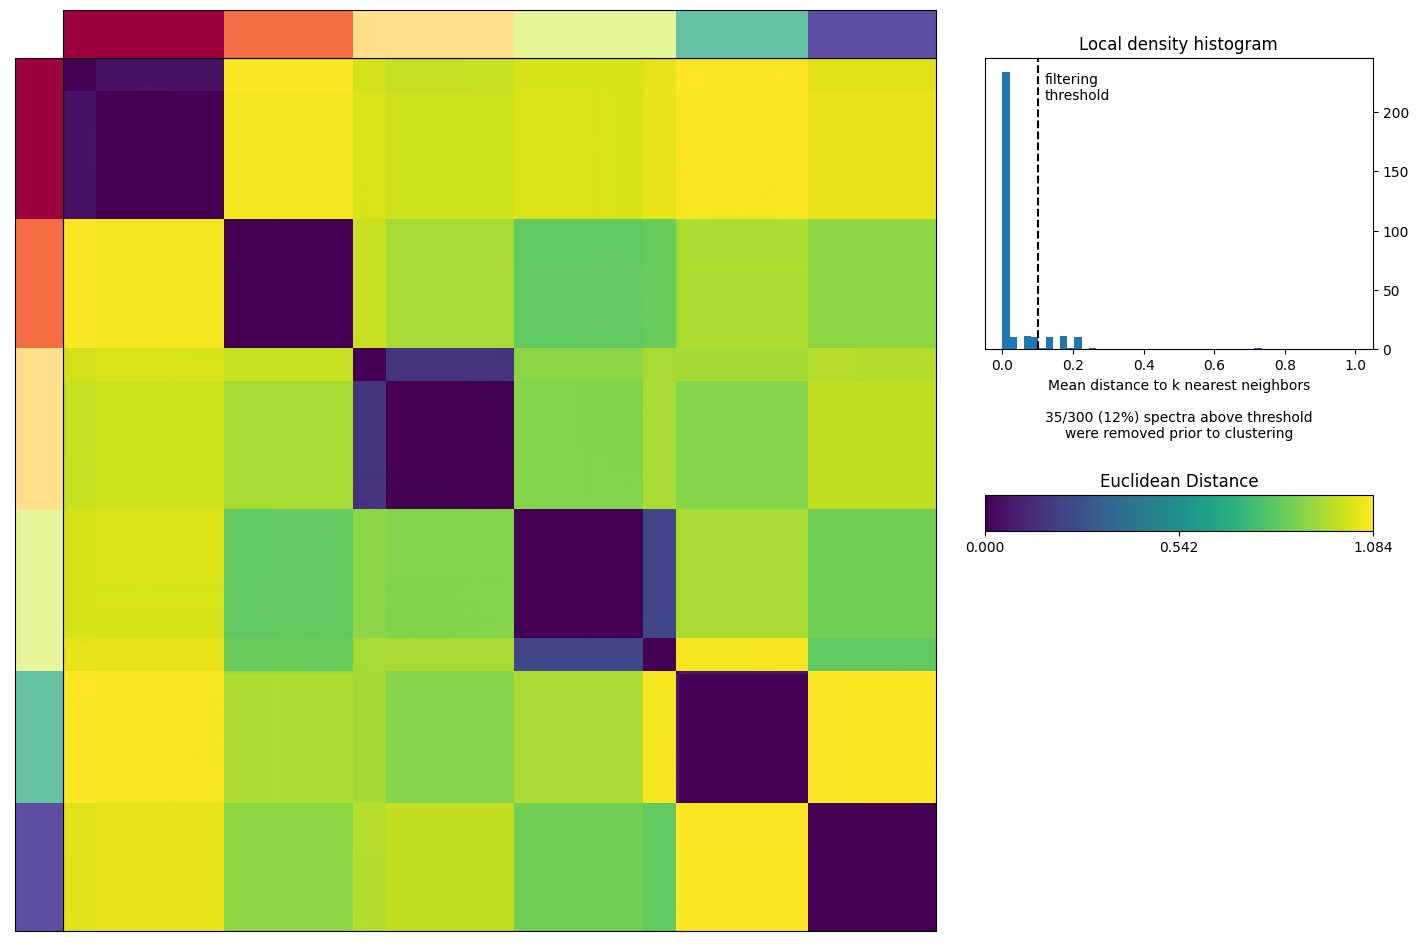

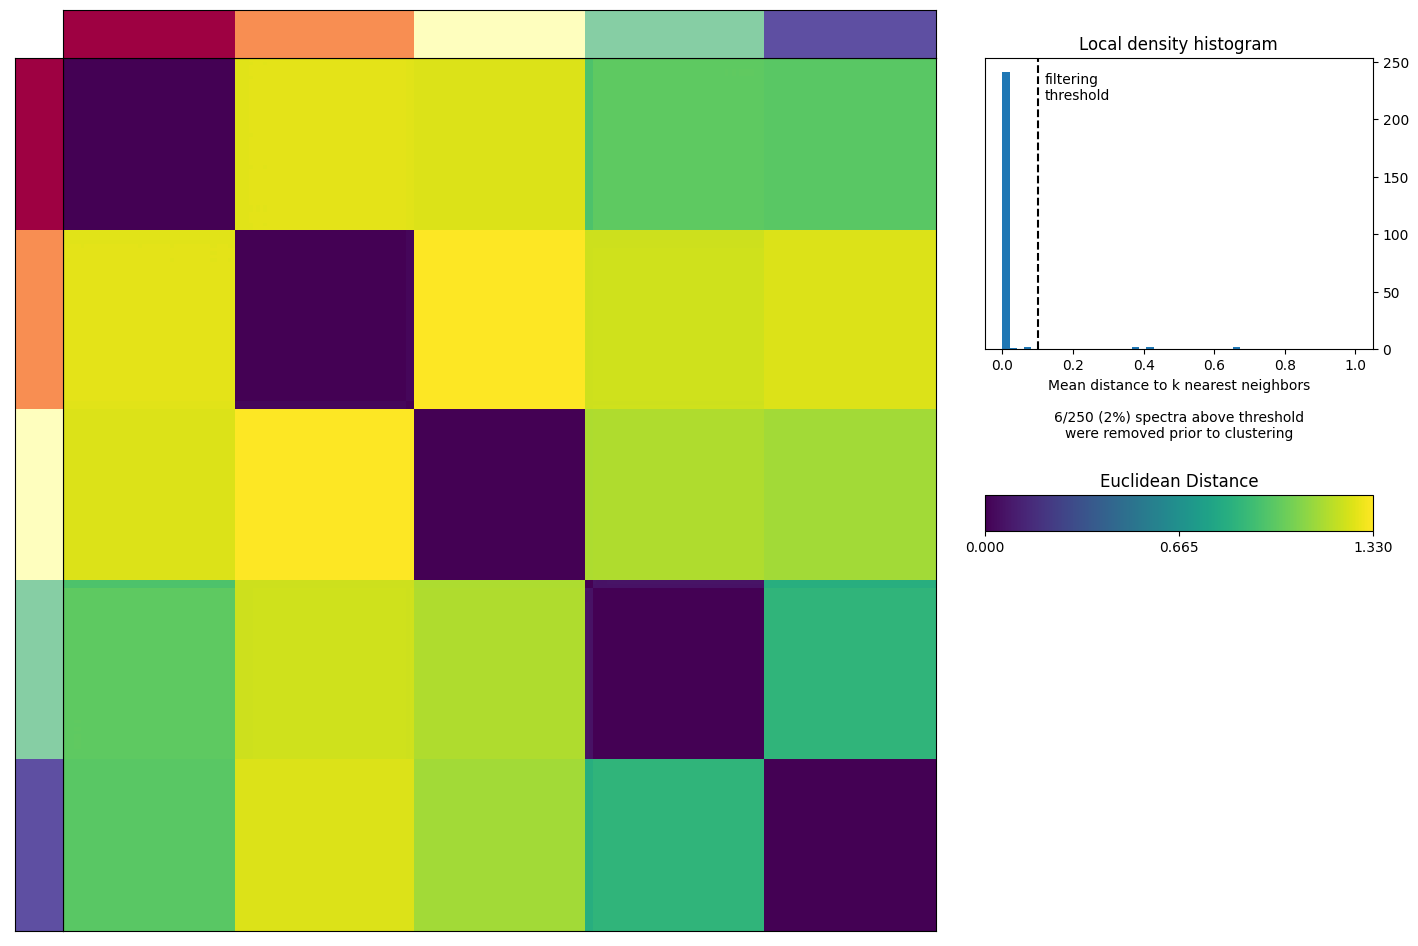

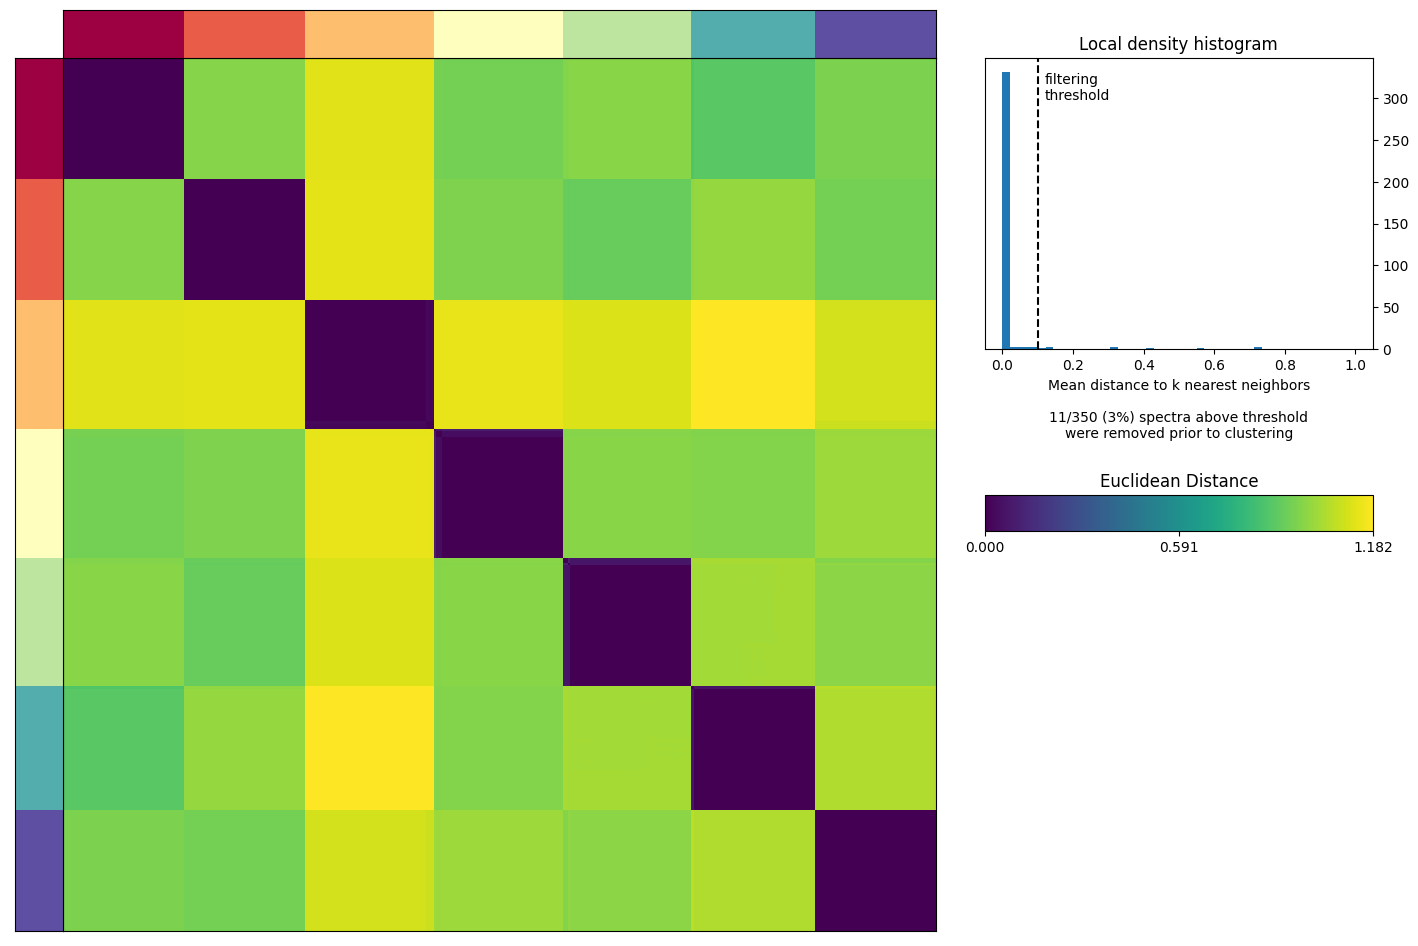

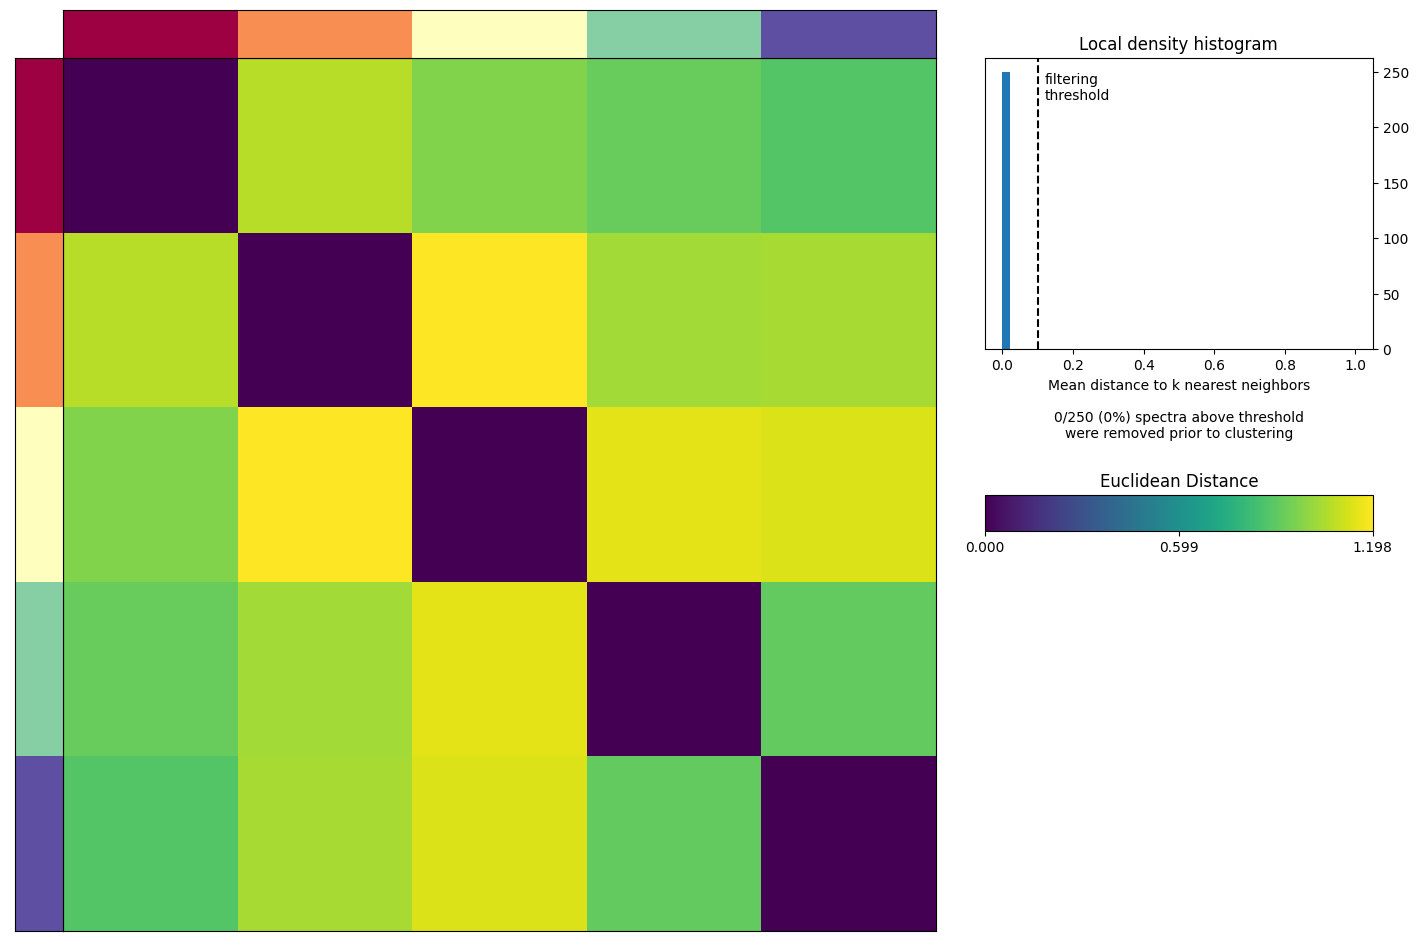

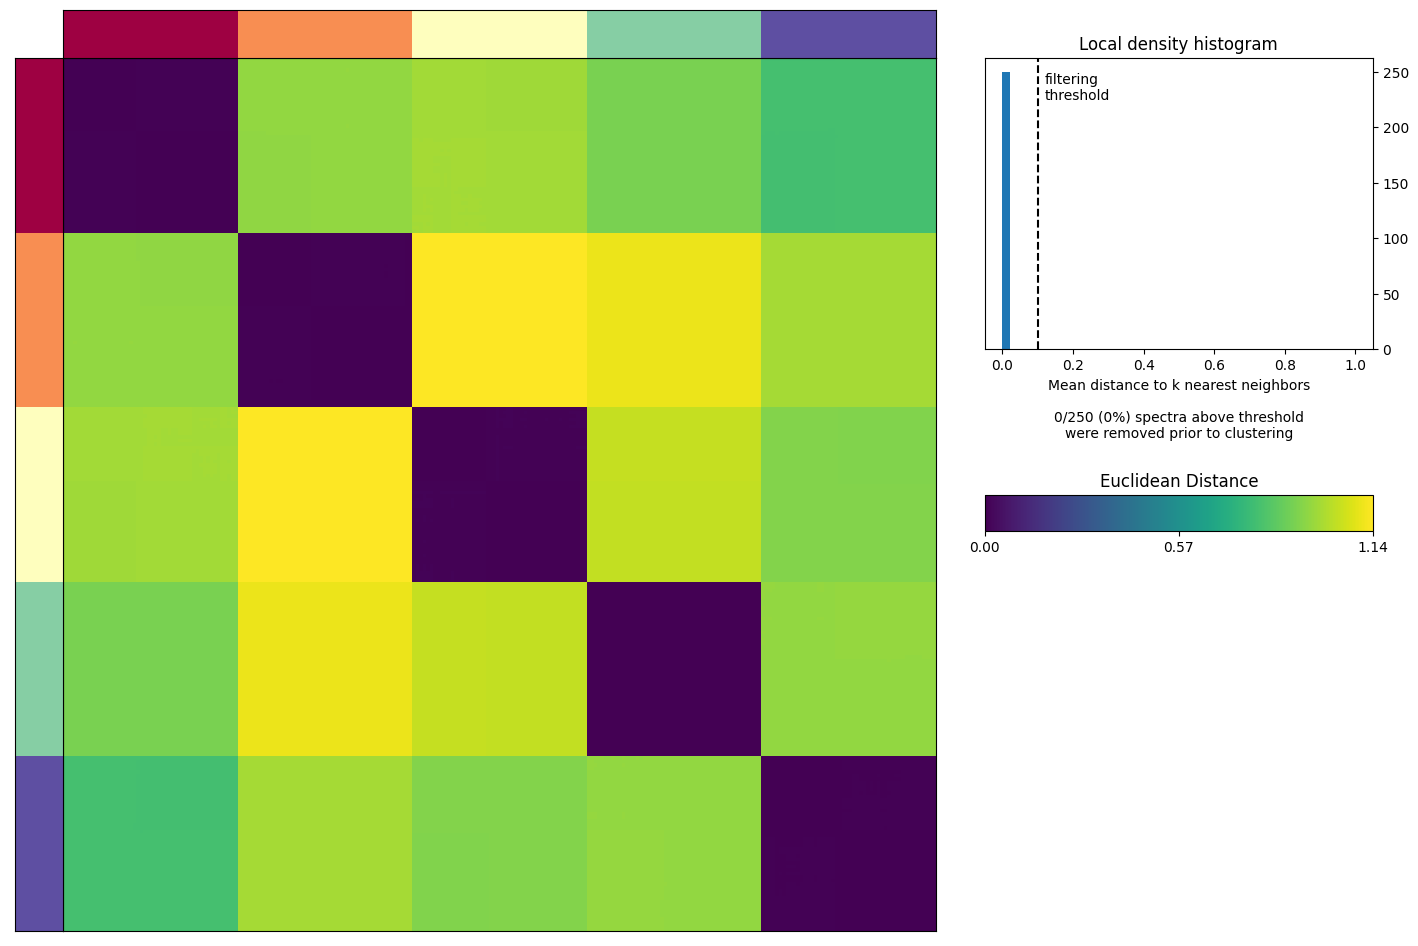

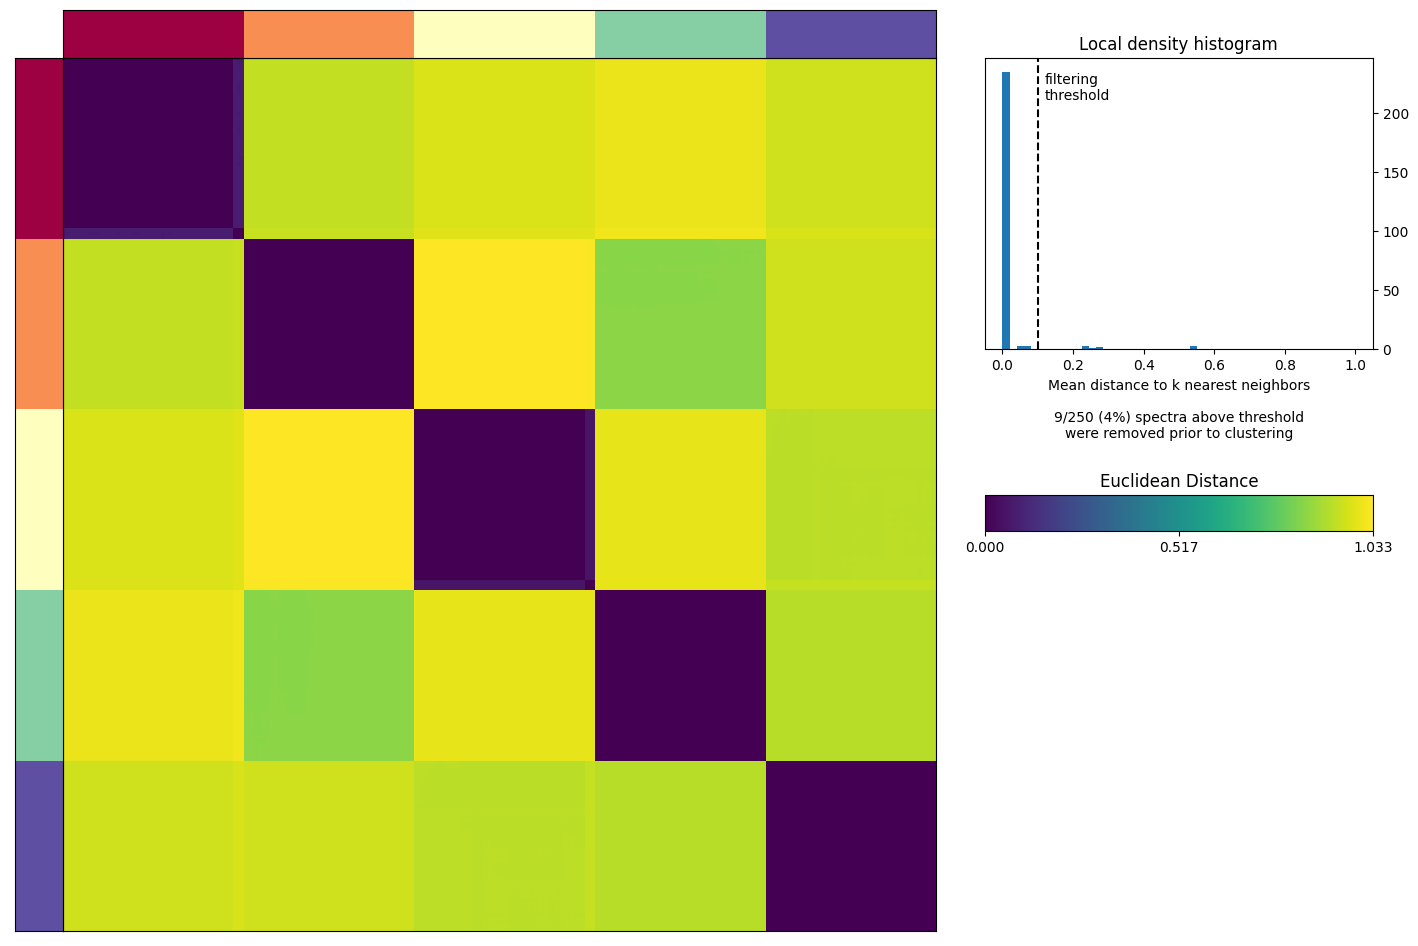

In [8]:
kfile = SDIR / "K_CHOSEN.csv"
kdf = pd.read_csv(kfile)
kdf["patient"] = kdf["patient"].astype(str)
kdf["chosen_k"] = pd.to_numeric(kdf["chosen_k"], errors="coerce").astype("Int64")

missing = kdf[kdf["chosen_k"].isna()]["patient"].tolist()
if len(missing) > 0:
    raise ValueError(f"These patients missing chosen_k in {kfile}: {missing}")

K_CHOSEN = dict(zip(kdf["patient"], kdf["chosen_k"].astype(int)))
print("K_CHOSEN head:", list(K_CHOSEN.items())[:5])

for pid, k in K_CHOSEN.items():
    out_p = PDIR / pid

    cn = cNMF(output_dir=str(PDIR), name=pid)  # ✅ 同一规则：PDIR + name=pid
    cn.consensus(k=k, density_threshold=DENSITY_THRESHOLD)

    usage, gep_scores, gep_tpm, top_genes = cn.load_results(K=k, density_threshold=DENSITY_THRESHOLD)

    # 统一导出为“逗号分隔 csv”，避免你之前 csv 实际是 tsv 的坑
    usage.to_csv(out_p / f"{pid}.usage_norm.k{k}.dt{DENSITY_THRESHOLD}.csv")
    gep_scores.to_csv(out_p / f"{pid}.gene_spectra_score.k{k}.dt{DENSITY_THRESHOLD}.csv")
    gep_tpm.to_csv(out_p / f"{pid}.gene_spectra_tpm.k{k}.dt{DENSITY_THRESHOLD}.csv")
    save_top_genes(top_genes, out_p / f"{pid}.top_genes.k{k}.dt{DENSITY_THRESHOLD}.csv")

    print(f"[EXPORT] {pid}: K={k}")


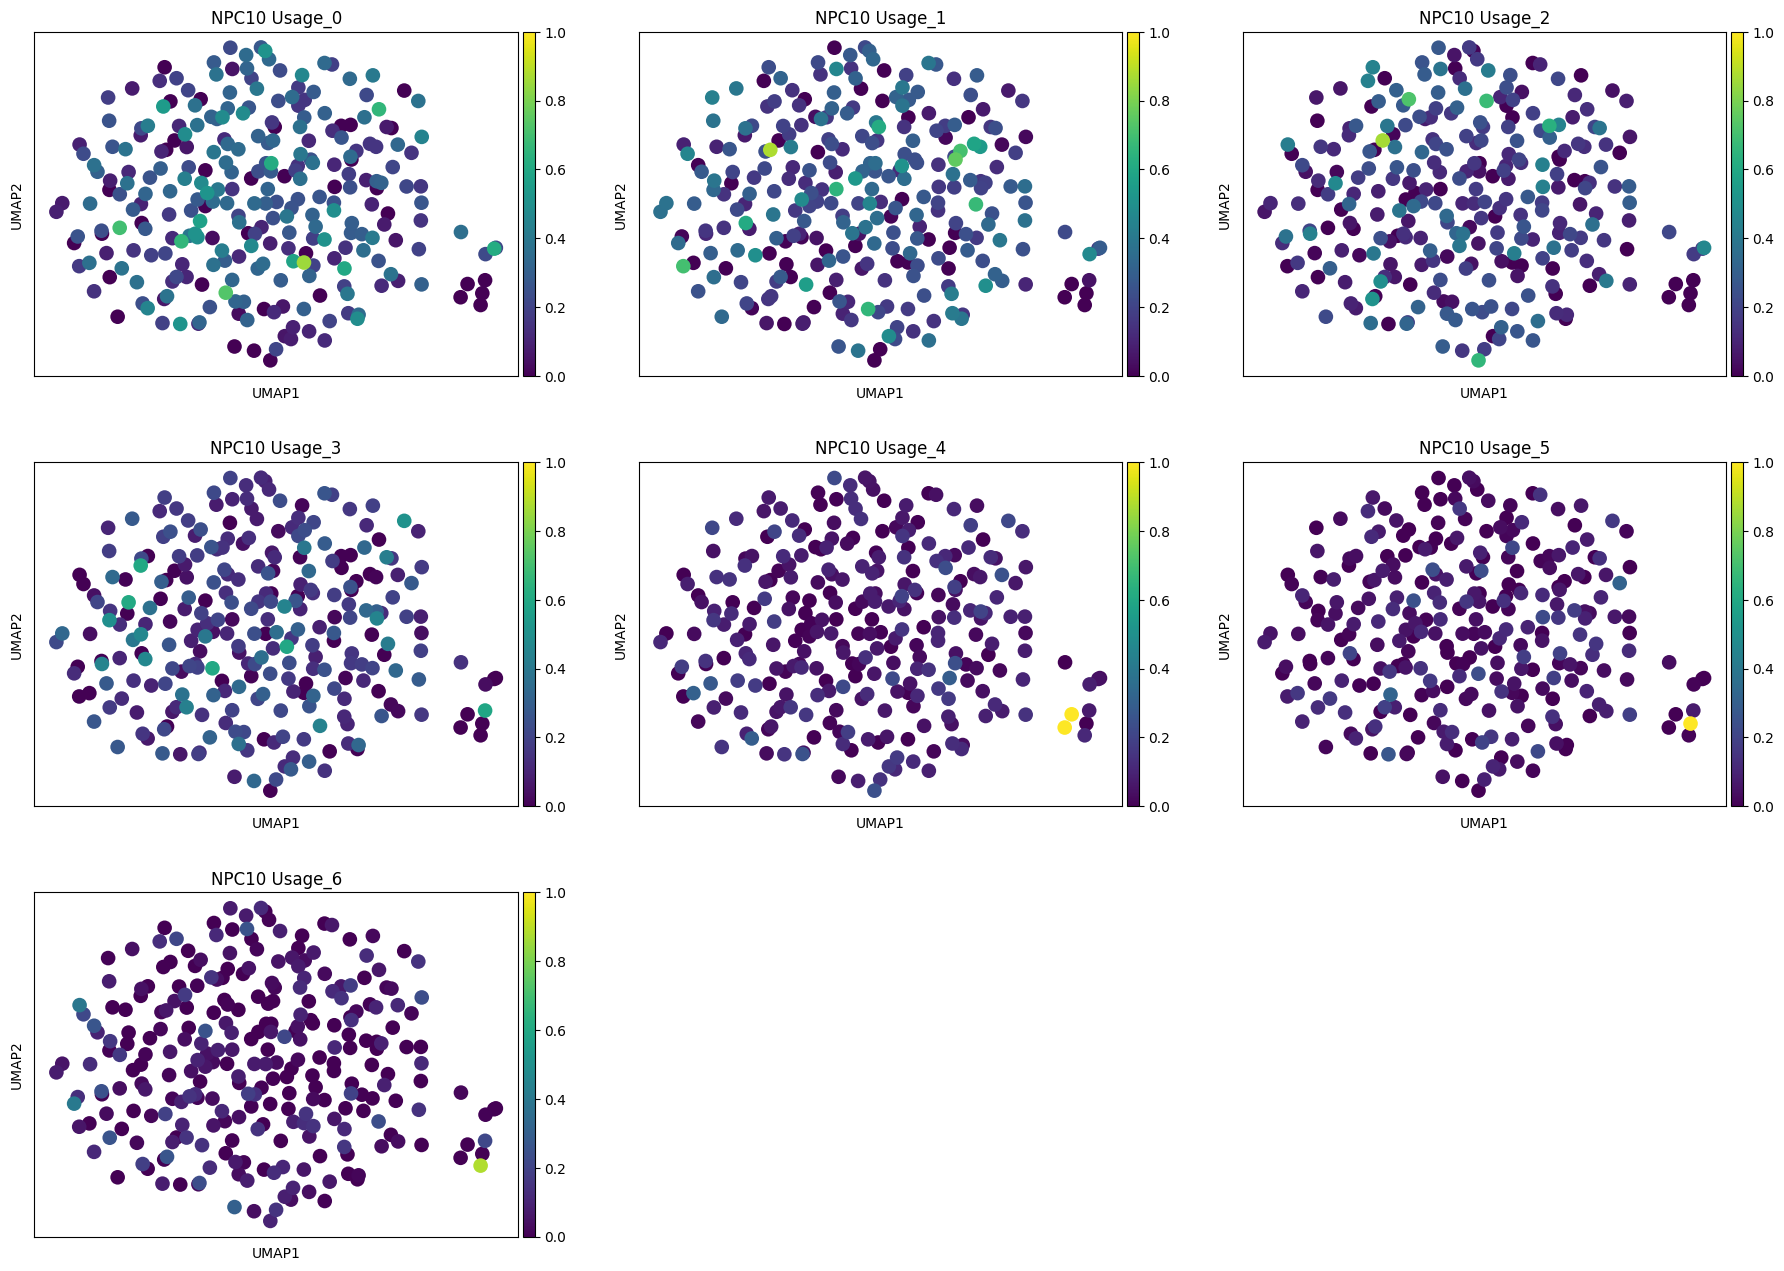

/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


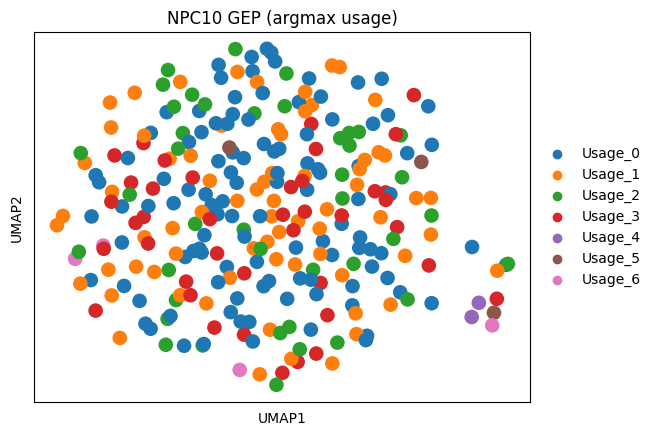

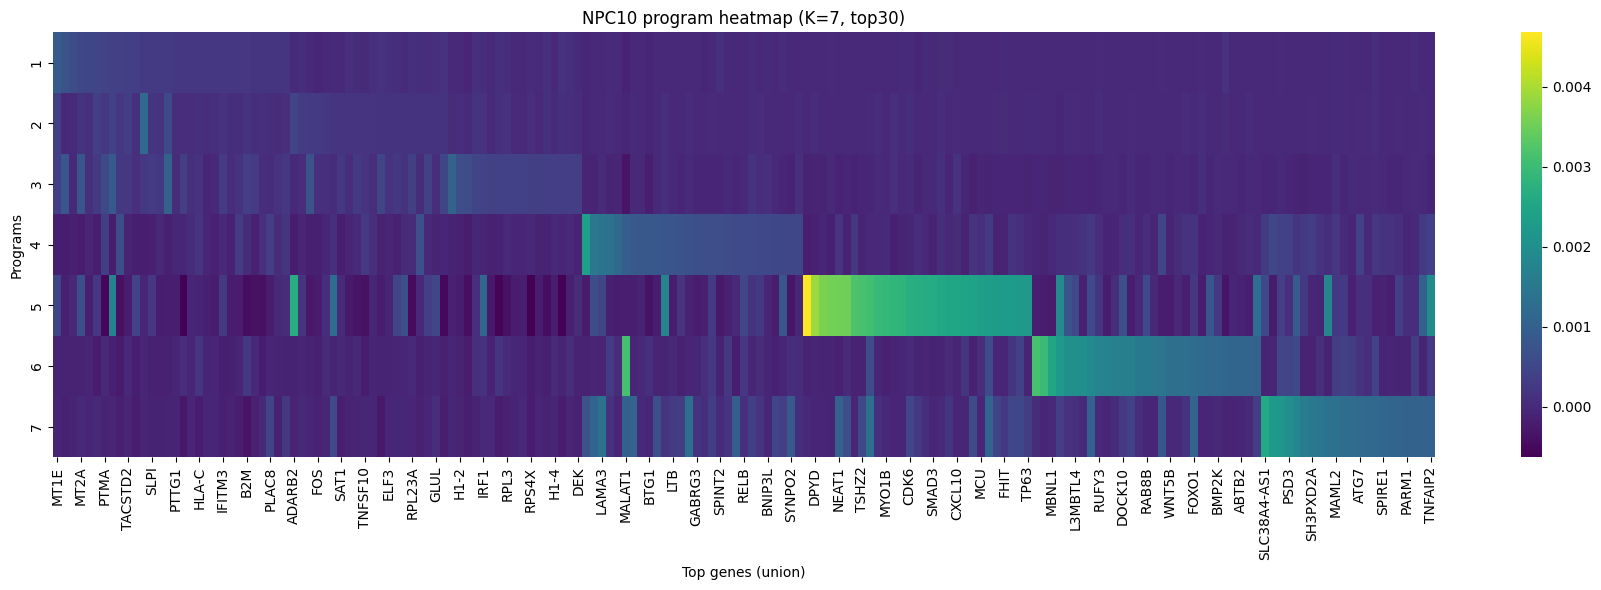

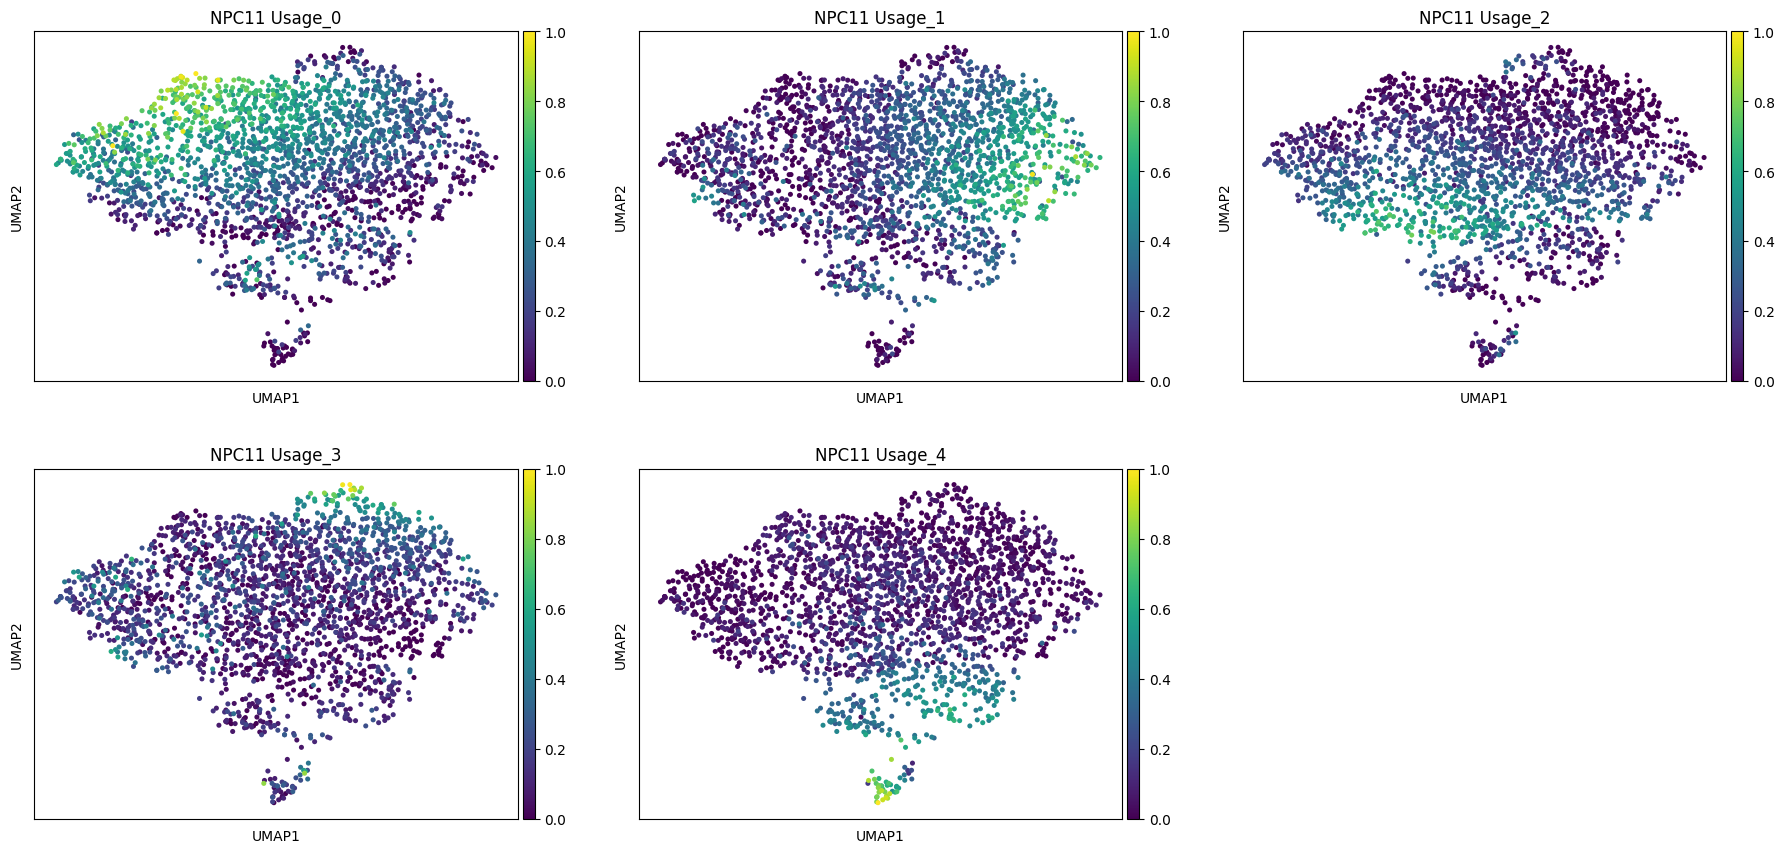

/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


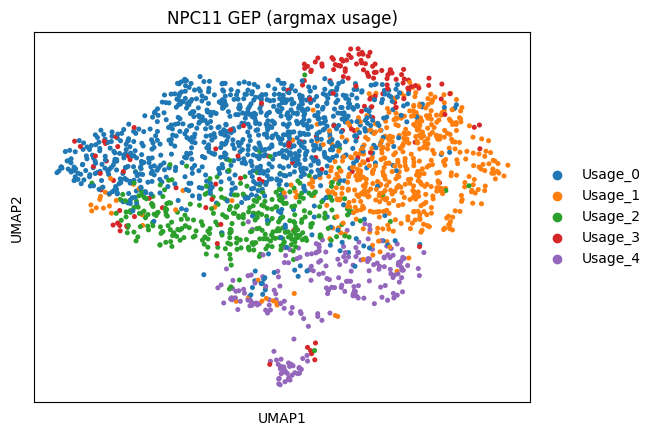

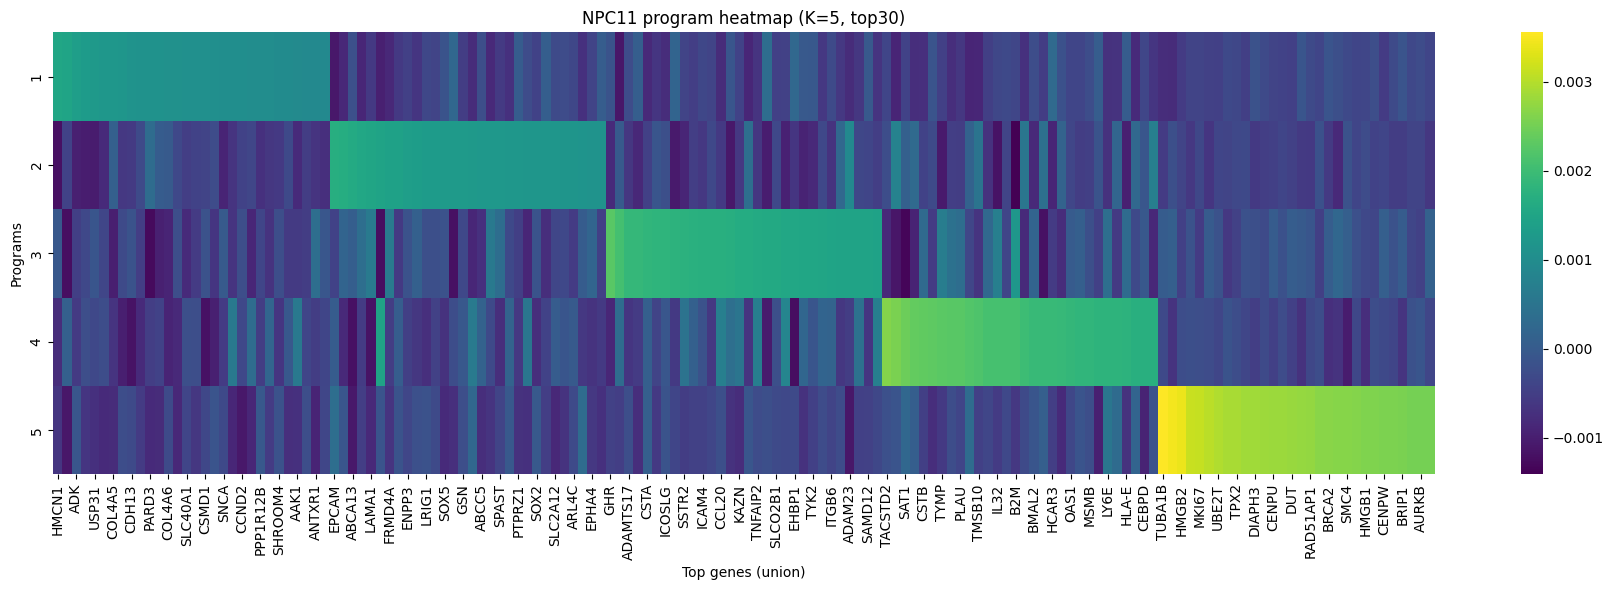

In [9]:
def plot_patient(pid: str):
    k = K_CHOSEN[pid]
    out_p = PDIR / pid

    usage = pd.read_csv(out_p / f"{pid}.usage_norm.k{k}.dt{DENSITY_THRESHOLD}.csv", index_col=0)
    usage.columns = [f"Usage_{i}" for i in range(usage.shape[1])]

    gep_scores = pd.read_csv(out_p / f"{pid}.gene_spectra_score.k{k}.dt{DENSITY_THRESHOLD}.csv", index_col=0)

    hvgs_path = out_p / f"{pid}.overdispersed_genes.txt"
    hvgs = pd.Index([x for x in hvgs_path.read_text().split("\n") if x])

    ad_p = adata_counts[adata_counts.obs[PATIENT_KEY].astype(str) == pid].copy()
    sc.pp.normalize_total(ad_p, target_sum=10000)
    sc.pp.log1p(ad_p)
    ad_p = ad_p[:, hvgs.intersection(ad_p.var_names)].copy()

    sc.tl.pca(ad_p)
    sc.pp.neighbors(ad_p)
    sc.tl.umap(ad_p)

    common = ad_p.obs_names.intersection(usage.index)
    ad_p = ad_p[common].copy()
    ad_p.obs = pd.concat([ad_p.obs, usage.loc[common]], axis=1)

    # UMAP usage
    sc.pl.umap(ad_p, color=list(usage.columns), ncols=3, vmin=0, vmax=1, title=[f"{pid} {c}" for c in usage.columns])

    # UMAP GEP
    ad_p.obs["GEP"] = usage.loc[common].idxmax(axis=1)
    sc.pl.umap(ad_p, color="GEP", title=f"{pid} GEP (argmax usage)")

    # Heatmap programs x top genes union
    prog_by_gene = gep_scores if gep_scores.shape[0] <= gep_scores.shape[1] else gep_scores.T  # programs x genes
    top_n = 30
    genes_union = []
    for prog in prog_by_gene.index:
        genes_union.extend(prog_by_gene.loc[prog].sort_values(ascending=False).head(top_n).index.tolist())
    genes_union = pd.Index(pd.unique(genes_union))
    mat = prog_by_gene.loc[:, genes_union]

    plt.figure(figsize=(min(18, 0.25*mat.shape[1] + 4), max(6, 0.4*mat.shape[0] + 2)))
    sns.heatmap(mat, cmap="viridis")
    plt.title(f"{pid} program heatmap (K={k}, top{top_n})")
    plt.xlabel("Top genes (union)")
    plt.ylabel("Programs")
    plt.tight_layout()
    plt.show()

# 先画 1-2 个确认，再全画
for pid in list(K_CHOSEN.keys())[:2]:
    plot_patient(pid)


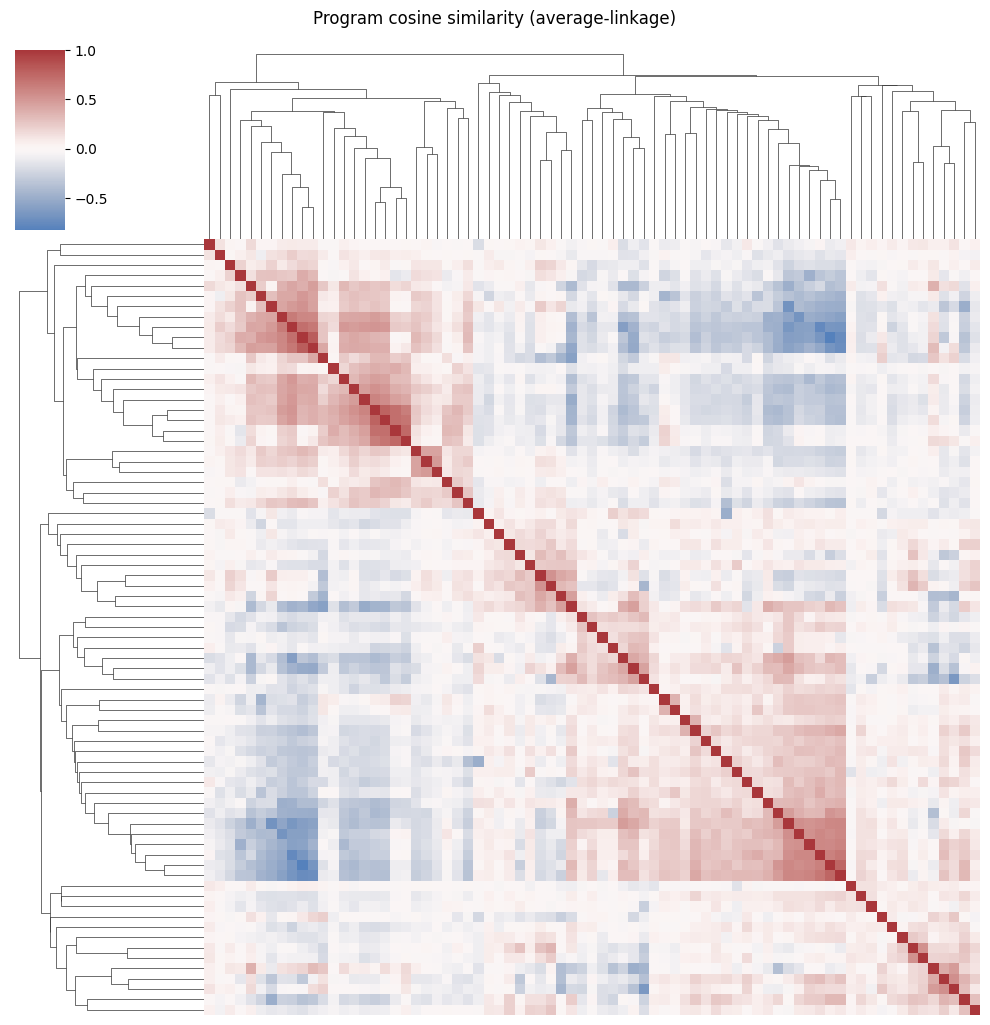

Saved to: cnmf_npc1/summary


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import scipy.cluster.hierarchy as sch

blocks = []
for pid, k in K_CHOSEN.items():
    out_p = PDIR / pid
    df = pd.read_csv(out_p / f"{pid}.gene_spectra_score.k{k}.dt{DENSITY_THRESHOLD}.csv", index_col=0)
    prog_by_gene = df if df.shape[0] <= df.shape[1] else df.T  # programs x genes
    prog_by_gene.index = [f"{pid}_Prog{i}" for i in range(prog_by_gene.shape[0])]
    blocks.append(prog_by_gene)

all_prog_by_gene = pd.concat(blocks, axis=0).fillna(0.0)  # programs x genes
X = all_prog_by_gene.values

cos_sim = pd.DataFrame(cosine_similarity(X), index=all_prog_by_gene.index, columns=all_prog_by_gene.index)
linkage = sch.linkage(X, method="average", metric="cosine")

g = sns.clustermap(
    cos_sim,
    row_linkage=linkage,
    col_linkage=linkage,
    cmap="vlag",
    center=0.0,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle("Program cosine similarity (average-linkage)", y=1.02)
plt.savefig(SDIR / "program_similarity_clustermap.png", dpi=300, bbox_inches="tight")
cos_sim.to_csv(SDIR / "program_cosine_similarity.csv")
plt.show()

print("Saved to:", SDIR)


In [11]:
qc_template = SDIR / "program_qc_template.csv"

rows = []
for pid, k in K_CHOSEN.items():
    out_p = PDIR / pid
    topf = out_p / f"{pid}.top_genes.k{k}.dt{DENSITY_THRESHOLD}.csv"
    if not topf.exists():
        raise FileNotFoundError(f"Missing top_genes for {pid}: {topf}")

    tg = pd.read_csv(topf)  # columns: program_0, program_1, ...
    for col in tg.columns:
        genes = tg[col].dropna().astype(str).tolist()
        idx = col.replace("program_", "")  # "0"
        prog = f"{pid}_Prog{idx}"          # 统一全局 program ID

        rows.append({
            "program": prog,
            "patient": pid,
            "keep": "",          # 你填 1/0
            "note": "",          # 你写原因：mito/ribo/stress/...
            "top_genes_30": ",".join(genes[:30]),
            "top_genes_50": ",".join(genes[:50]),
        })

qc_df = pd.DataFrame(rows)
qc_df.to_csv(qc_template, index=False)
print("Wrote:", qc_template, "n_programs =", qc_df.shape[0])
qc_df.head()


Wrote: cnmf_npc1/summary/program_qc_template.csv n_programs = 75


,program,patient,keep,note,top_genes_30,top_genes_50
0,NPC10_Prog1,NPC10,,,"MT1E,IFI27,AGR2,MT2A,GPX2,WFDC2,PTMA,S100A2,KR...","MT1E,IFI27,AGR2,MT2A,GPX2,WFDC2,PTMA,S100A2,KR..."
1,NPC10_Prog2,NPC10,,,"MT1X,SERPINB3,ADARB2,S100A2,MT1E,WFDC2,TACSTD2...","MT1X,SERPINB3,ADARB2,S100A2,MT1E,WFDC2,TACSTD2..."
2,NPC10_Prog3,NPC10,,,"LY6D,SERPINB3,S100A2,MT2A,IFI27,HES1,H1-2,H4C3...","LY6D,SERPINB3,S100A2,MT2A,IFI27,HES1,H1-2,H4C3..."
3,NPC10_Prog4,NPC10,,,"GPNMB,SFXN1,LAMA3,7SK.4,GPI,MALAT1,DYNC2I1,HIL...","GPNMB,SFXN1,LAMA3,7SK.4,GPI,MALAT1,DYNC2I1,HIL..."
4,NPC10_Prog5,NPC10,,,"NRG1,DPYD,TNS3,ITPKC,NEAT1,NFAT5,LAMB3,TSHZ2,J...","NRG1,DPYD,TNS3,ITPKC,NEAT1,NFAT5,LAMB3,TSHZ2,J..."


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import scipy.cluster.hierarchy as sch

# 汇总 programs x genes（来自每患者 gene_spectra_score）
blocks = []
for pid, k in K_CHOSEN.items():
    out_p = PDIR / pid
    f = out_p / f"{pid}.gene_spectra_score.k{k}.dt{DENSITY_THRESHOLD}.csv"
    df = pd.read_csv(f, index_col=0)
    prog_by_gene = df if df.shape[0] <= df.shape[1] else df.T  # programs x genes
    prog_by_gene.index = [f"{pid}_Prog{i+1}" for i in range(prog_by_gene.shape[0])]
    blocks.append(prog_by_gene)

all_prog_by_gene = pd.concat(blocks, axis=0).fillna(0.0)  # programs x genes
print("all_prog_by_gene:", all_prog_by_gene.shape)
all_prog_by_gene.head()


all_prog_by_gene: (75, 19617)


,TMEM51,FBXO42,RER1,VPS13D,SZRD1,LAPTM5,PHACTR4,SLC9A1,ATP5IF1,DNAJC8,...,HMGN2P15,GHRH,IGLV1-36,IGFBPL1,PNMA8A,RGL3,AZGP1P1,CA9,LRRC9,NCOR1P4
NPC10_Prog1,-0.000016,-0.000007,0.000018,-0.000003,-8.988228e-08,-0.000016,-0.000009,-0.000004,0.000039,8.039318e-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NPC10_Prog2,-0.000020,-0.000012,0.000007,0.000012,-1.539849e-05,-0.000033,0.000033,-0.000008,0.000016,8.206256e-07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NPC10_Prog3,-0.000013,-0.000058,-0.000013,0.000008,-5.220725e-05,-0.000013,0.000038,-0.000037,0.000088,6.793518e-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NPC10_Prog4,0.000328,-0.000044,-0.000078,0.000023,3.758972e-05,-0.000057,0.000185,-0.000085,-0.000090,3.774995e-05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NPC10_Prog5,0.000687,-0.000114,-0.000149,-0.000155,1.500696e-04,-0.000062,-0.000172,0.001342,-0.000066,-1.750494e-04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
qc_file = SDIR / "program_qc_keep.csv"
qc = pd.read_csv(qc_file)
qc["program"] = qc["program"].astype(str).str.strip()
qc["keep"] = pd.to_numeric(qc["keep"], errors="coerce").fillna(0).astype(int)

keep_programs = qc.loc[qc["keep"] == 1, "program"].tolist()
keep_programs = [p for p in keep_programs if p in all_prog_by_gene.index]
print("kept programs:", len(keep_programs), "/", all_prog_by_gene.shape[0])

prog_keep = all_prog_by_gene.loc[keep_programs].copy()
X = prog_keep.values

cos_sim = pd.DataFrame(
    cosine_similarity(X),
    index=prog_keep.index,
    columns=prog_keep.index
)
linkage = sch.linkage(X, method="average", metric="cosine")


kept programs: 59 / 75


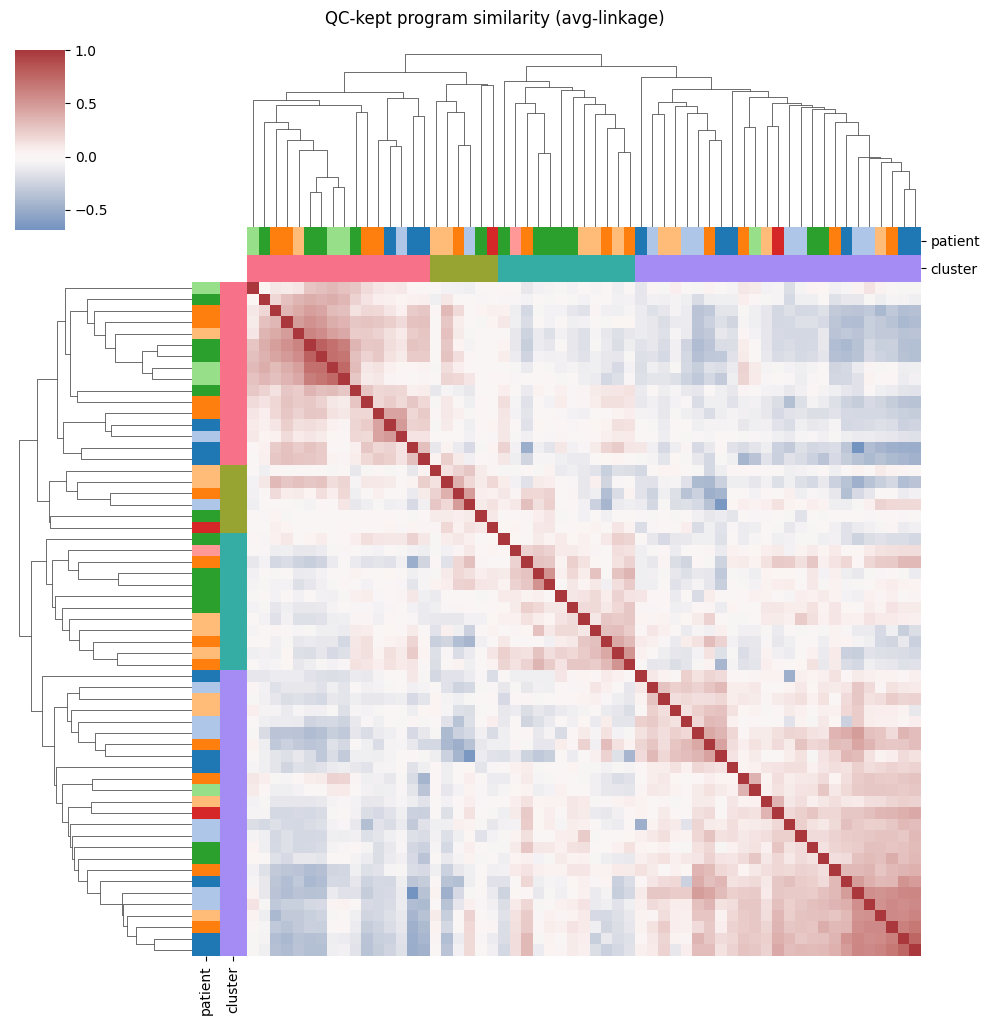

Saved: cnmf_npc1/summary/program_similarity_clustermap_QCkept.png


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

def prog_to_patient(p):  # NPC10_Prog0 -> NPC10
    return p.split("_")[1]

# 患者颜色条
patients = sorted({prog_to_patient(p) for p in prog_keep.index})
pal_pat = sns.color_palette("tab20", n_colors=len(patients))
pat_color = dict(zip(patients, pal_pat))
row_patient = pd.Series([pat_color[prog_to_patient(p)] for p in prog_keep.index], index=prog_keep.index)

# 设定 program clusters 数（你可调）
N_CLUSTERS =4
cluster_id = sch.fcluster(linkage, t=N_CLUSTERS, criterion="maxclust")
cluster_id = pd.Series(cluster_id, index=prog_keep.index, name="cluster")

pal_clu = sns.color_palette("husl", n_colors=N_CLUSTERS)
clu_color = {i+1: pal_clu[i] for i in range(N_CLUSTERS)}
row_cluster = pd.Series([clu_color[c] for c in cluster_id.loc[prog_keep.index]], index=prog_keep.index)

row_colors = pd.DataFrame({"patient": row_patient, "cluster": row_cluster}, index=prog_keep.index)

g = sns.clustermap(
    cos_sim,
    row_linkage=linkage,
    col_linkage=linkage,
    row_colors=row_colors,
    col_colors=row_colors,
    cmap="vlag",
    center=0.0,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle("QC-kept program similarity (avg-linkage)", y=1.02)
plt.savefig(SDIR / "program_similarity_clustermap_QCkept.pdf", bbox_inches="tight")
plt.show()
print("Saved:", SDIR / "program_similarity_clustermap_QCkept.png")


In [21]:
assign = pd.DataFrame({
    "program": prog_keep.index,
    "patient": [prog_to_patient(p) for p in prog_keep.index],
    "cluster": cluster_id.loc[prog_keep.index].values
}).merge(qc[["program","note"]], on="program", how="left")

assign.to_csv(SDIR / "program_cluster_assignments.csv", index=False)
assign.head()


,program,patient,cluster,note
0,NPC10_Prog1,Prog1,1,NaN
1,NPC10_Prog2,Prog2,1,NaN
2,NPC10_Prog3,Prog3,1,NaN
3,NPC10_Prog4,Prog4,4,NaN
4,NPC10_Prog5,Prog5,4,NaN


In [22]:
def load_usage(pid: str):
    k = K_CHOSEN[pid]
    out_p = PDIR / pid
    u = pd.read_csv(out_p / f"{pid}.usage_norm.k{k}.dt{DENSITY_THRESHOLD}.csv", index_col=0)
    u.columns = [f"{pid}_Prog{i}" for i in range(u.shape[1])]
    return u


/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


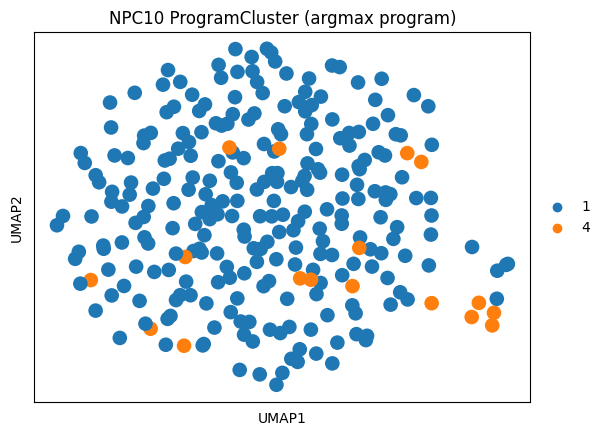

In [23]:
prog2clu = dict(zip(assign["program"], assign["cluster"]))

# 先挑一个患者测试
pid = list(K_CHOSEN.keys())[0]

usage = load_usage(pid)
# 只保留 QC-kept programs
usage = usage[[c for c in usage.columns if c in prog2clu]]

cell_best_prog = usage.idxmax(axis=1)
cell_cluster = cell_best_prog.map(prog2clu).astype("Int64")

# 做该患者的 UMAP（仍用 cNMF HVGs）
out_p = PDIR / pid
hvgs = pd.Index([x for x in (out_p / f"{pid}.overdispersed_genes.txt").read_text().split("\n") if x])

ad_p = adata_counts[adata_counts.obs[PATIENT_KEY].astype(str) == pid].copy()
sc.pp.normalize_total(ad_p, target_sum=10000)
sc.pp.log1p(ad_p)
ad_p = ad_p[:, hvgs.intersection(ad_p.var_names)].copy()
sc.tl.pca(ad_p); sc.pp.neighbors(ad_p); sc.tl.umap(ad_p)

common = ad_p.obs_names.intersection(cell_cluster.index)
ad_p = ad_p[common].copy()
ad_p.obs["ProgramCluster"] = cell_cluster.loc[common].astype(str)

sc.pl.umap(ad_p, color="ProgramCluster", title=f"{pid} ProgramCluster (argmax program)")


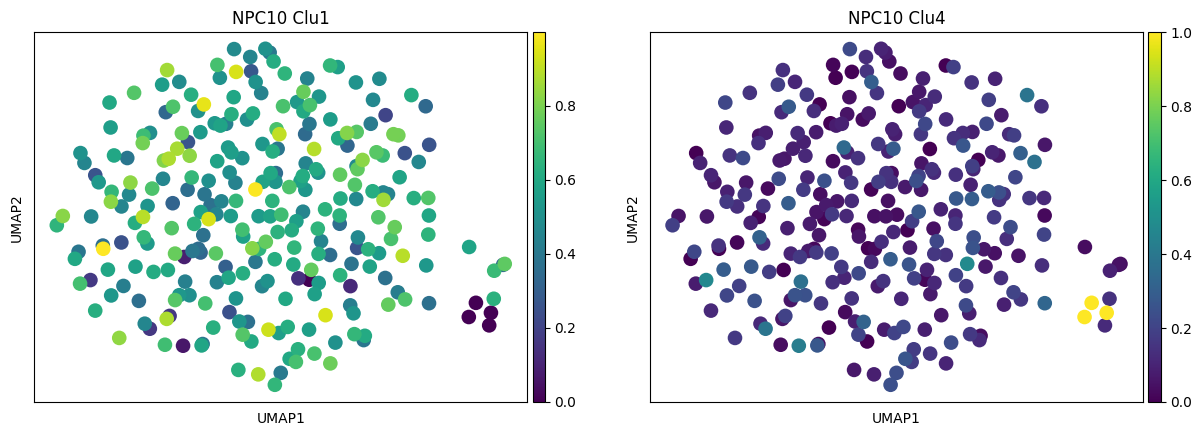

In [24]:
# cluster -> programs（只包含该患者的）
clu2progs = assign.groupby("cluster")["program"].apply(list).to_dict()

cluster_usage = pd.DataFrame(index=usage.index)
for clu, progs in clu2progs.items():
    progs_use = [p for p in progs if p in usage.columns]
    if len(progs_use) == 0:
        continue
    cluster_usage[f"Clu{clu}"] = usage[progs_use].sum(axis=1)

common = ad_p.obs_names.intersection(cluster_usage.index)
ad_p2 = ad_p[common].copy()
ad_p2.obs = pd.concat([ad_p2.obs, cluster_usage.loc[common]], axis=1)

# 画前几个 cluster（全画会很多）
cols = list(cluster_usage.columns)[:6]
sc.pl.umap(ad_p2, color=cols, ncols=3, title=[f"{pid} {c}" for c in cols])


In [25]:
def build_meta_programs(prog_by_gene_df, assign_df, top_n=100):
    """
    prog_by_gene_df: programs x genes, 行名必须是 program 名
    assign_df: 至少包含 columns ['program', 'cluster', 'patient']
    top_n: 每个 meta-program 取前多少基因

    返回：
    1) mp_gene_weights: meta-program x gene 的完整中位权重矩阵
    2) mp_topgenes_long: 长表，每个 meta-program 前top_n基因及权重
    3) mp_summary: 汇总表，每个 meta-program 的top基因字符串
    """
    # 只保留能对上的 programs
    assign_use = assign_df[assign_df["program"].isin(prog_by_gene_df.index)].copy()

    mp_weight_list = []
    top_rows = []
    summary_rows = []

    for clu, sub in assign_use.groupby("cluster"):
        progs = sub["program"].tolist()
        mat = prog_by_gene_df.loc[progs]   # programs x genes

        # 关键：按文献方法取中位数，不是均值
        median_w = mat.median(axis=0).sort_values(ascending=False)

        # 可选：去掉线粒体/核糖体等干扰基因
        median_w = median_w.loc[
            ~median_w.index.str.startswith(("MT-", "RPS", "RPL"))
        ]

        mp_name = f"MP{int(clu)}"

        # 保存完整权重向量
        mp_weight_list.append(pd.Series(median_w, name=mp_name))

        # 保存前100基因及权重（长表）
        top_s = median_w.head(top_n)
        tmp = pd.DataFrame({
            "meta_program": mp_name,
            "cluster": int(clu),
            "rank": range(1, len(top_s) + 1),
            "gene": top_s.index,
            "weight": top_s.values,
            "n_programs": len(progs),
            "patients": ",".join(sorted(set(sub["patient"])))
        })
        top_rows.append(tmp)

        # 保存汇总表
        summary_rows.append({
            "meta_program": mp_name,
            "cluster": int(clu),
            "n_programs": len(progs),
            "patients": ",".join(sorted(set(sub["patient"]))),
            "top_genes": ",".join(top_s.index.tolist())
        })

    # 合并完整权重矩阵：rows = MP, cols = genes
    mp_gene_weights = pd.DataFrame(mp_weight_list)
    mp_gene_weights.index.name = "meta_program"

    mp_topgenes_long = pd.concat(top_rows, axis=0, ignore_index=True)
    mp_summary = pd.DataFrame(summary_rows).sort_values("cluster")

    return mp_gene_weights, mp_topgenes_long, mp_summary

In [26]:
# ====== 构建最终 meta-program ======
mp_gene_weights, mp_top100_long, mp_summary = build_meta_programs(
    prog_by_gene_df=prog_keep,   # 这里就是 QC-kept 的 programs x genes
    assign_df=assign,
    top_n=100
)

# 导出
mp_gene_weights.to_csv(SDIR / "meta_program_gene_weights_median.csv")
mp_top100_long.to_csv(SDIR / "meta_program_top100_genes_with_weights.csv", index=False)
mp_summary.to_csv(SDIR / "meta_program_summary.csv", index=False)

print(mp_gene_weights.shape)
print(mp_top100_long.head(20))
print(mp_summary)

(4, 19190)
   meta_program  cluster  rank    gene    weight  n_programs  \
0           MP1        1     1   CENPF  0.001232          16   
1           MP1        1     2   HMGB2  0.001078          16   
2           MP1        1     3    ASPM  0.001042          16   
3           MP1        1     4     PBK  0.001026          16   
4           MP1        1     5   HMGN2  0.000919          16   
5           MP1        1     6   BIRC5  0.000914          16   
6           MP1        1     7   H2AZ1  0.000902          16   
7           MP1        1     8  TUBA1B  0.000853          16   
8           MP1        1     9   UBE2C  0.000851          16   
9           MP1        1    10  DIAPH3  0.000839          16   
10          MP1        1    11   CENPE  0.000835          16   
11          MP1        1    12   CCNB1  0.000825          16   
12          MP1        1    13   HMGB1  0.000796          16   
13          MP1        1    14    TPX2  0.000792          16   
14          MP1        1    1

In [52]:
#均值方法
def top_genes_per_cluster(prog_by_gene_df, assign_df, top_n=100):
    out = []
    for clu, sub in assign_df.groupby("cluster"):
        progs = sub["program"].tolist()
        mat = prog_by_gene_df.loc[progs]
        mean_w = mat.mean(axis=0).sort_values(ascending=False)
        out.append({
            "cluster": int(clu),
            "n_programs": len(progs),
            "patients": ",".join(sorted(set(sub["patient"]))),
            "top_genes": ",".join(mean_w.index[:top_n].tolist()),
        })
    return pd.DataFrame(out).sort_values("cluster")

cluster_genes = top_genes_per_cluster(prog_keep, assign, top_n=100)
cluster_genes.to_csv(SDIR / "cluster_top_genes.csv", index=False)
cluster_genes

,cluster,n_programs,patients,top_genes
0,1,17,"NPC10,NPC11,NPC12,NPC14,NPC16,NPC19,NPC22,NPC2...","HMGB2,TUBA1B,DIAPH3,TOP2A,MKI67,H2AZ1,PCLAF,TK..."
1,2,13,"NPC11,NPC12,NPC13,NPC14,NPC16,NPC19,NPC20,NPC2...","CXCL10,SOD2,CCL5,CCL20,SFN,CXCL8,GBP4,CXCL11,I..."
2,3,6,"NPC11,NPC12,NPC19,NPC20,NPC27","ELF3,KRT8,PLEKHA5,CLDN4,SOX4,SAT1,IGFBP5,AGR2,..."
3,4,17,"NPC10,NPC13,NPC16,NPC19,NPC26,NPC27,NPC29,NPC3","ROBO1,PARD3B,MAGI1,SYNPO2,FTX,RAI14,IMMP2L,SLC..."


In [27]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from pathlib import Path

# =========================
# 输入对象
# =========================
# adata: 你最开始读入的完整对象（malignant_patients.h5ad）
# mp_top100_long: 你在 In[51] 生成的 meta-program top100 基因长表
# SDIR: 输出目录
# COUNT_LAYER: 原始计数层名，比如 "counts_RNA"

# ---------- 1. 准备所有 meta-program 的 signature ----------
# 从 mp_top100_long 提取每个 MP 的前100基因
mp_signatures = (
    mp_top100_long.sort_values(["meta_program", "rank"])
    .groupby("meta_program")["gene"]
    .apply(list)
    .to_dict()
)

print("Meta-program signatures:")
for k, v in mp_signatures.items():
    print(k, len(v), v[:10])

# ---------- 2. 构建用于打分的表达对象 ----------
# 注意：scanpy score_genes 通常应使用 log-normalized expression，而不是 raw counts
adata_score = adata.copy()

# 若希望明确从 counts 层出发重新标准化，可这样做：
if COUNT_LAYER in adata_score.layers:
    adata_score.X = adata_score.layers[COUNT_LAYER].copy()
else:
    print(f"[WARN] layer {COUNT_LAYER} not found, use current adata.X for scoring")

# 归一化 + log1p
sc.pp.normalize_total(adata_score, target_sum=1e4)
sc.pp.log1p(adata_score)

# 可选：保留一个备份
adata_score.raw = adata_score

# ---------- 3. 逐个 meta-program 打分 ----------
score_cols = []

for mp, genes in mp_signatures.items():
    # 只保留对象中真实存在的基因
    genes_use = [g for g in genes if g in adata_score.var_names]

    if len(genes_use) < 5:
        print(f"[SKIP] {mp}: only {len(genes_use)} genes found in adata.var_names")
        continue

    score_name = f"{mp}_score"
    score_cols.append(score_name)

    # scanpy scoring:
    # 平均signature基因表达 - 平均control基因表达
    sc.tl.score_genes(
        adata_score,
        gene_list=genes_use,
        score_name=score_name,
        ctrl_size=min(50, len(genes_use)),  # 常用设置，比较稳
        n_bins=25,
        random_state=0,
        use_raw=False
    )

    print(f"[DONE] {mp}: {len(genes_use)} genes used")

# ---------- 4. 把分数写回原始 adata.obs ----------
for col in score_cols:
    adata.obs[col] = adata_score.obs[col].astype(float)

# 也把每个细胞最高分的 meta-program 写进去
if len(score_cols) > 0:
    score_mat = adata.obs[score_cols].copy()
    adata.obs["meta_program_max"] = score_mat.idxmax(axis=1).str.replace("_score", "", regex=False)
    adata.obs["meta_program_max_score"] = score_mat.max(axis=1)

# ---------- 5. 把 signature 信息写入 uns，方便以后复用 ----------
adata.uns["meta_program_signatures"] = mp_signatures
adata.uns["meta_program_score_columns"] = score_cols

# ---------- 6. 保存新的 h5ad ----------
out_h5ad = SDIR / "malignant_patients_with_meta_program_scores.h5ad"
adata.write(out_h5ad)

print(f"[SAVED] {out_h5ad}")
print("Added columns:", score_cols + ["meta_program_max", "meta_program_max_score"])

Meta-program signatures:
MP1 100 ['CENPF', 'HMGB2', 'ASPM', 'PBK', 'HMGN2', 'BIRC5', 'H2AZ1', 'TUBA1B', 'UBE2C', 'DIAPH3']
MP2 100 ['SPIB', 'KDM2B', 'SYT1', 'HLA-DRA', 'GRHPR', 'UVRAG', 'LGALS9', 'DNM3', 'CCL20', 'CD74']
MP3 100 ['SFN', 'GBP1', 'BMAL2', 'PARP14', 'B2M', 'TNFSF10', 'GBP4', 'CXCL10', 'TYMP', 'IDO1']
MP4 100 ['SDK1', 'EXOC6B', 'RERE', 'KIAA1217', 'COL4A5', 'MALAT1', 'ANK3', 'BCAS3', 'FTX', 'TFDP2']
[DONE] MP1: 100 genes used
[DONE] MP2: 100 genes used
[DONE] MP3: 100 genes used
[DONE] MP4: 100 genes used
[SAVED] cnmf_npc1/summary/malignant_patients_with_meta_program_scores.h5ad
Added columns: ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'meta_program_max', 'meta_program_max_score']


['doublet_score', 'MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'meta_program_max_score']


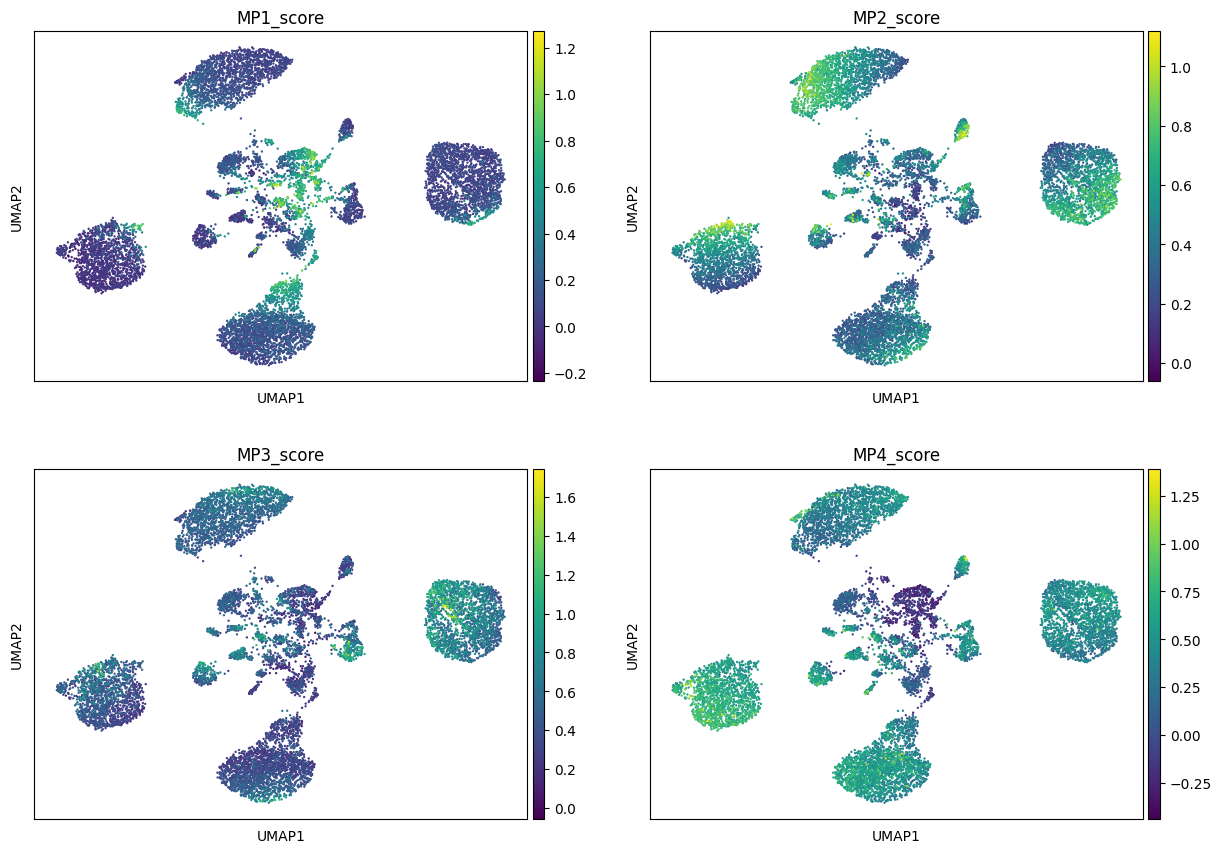

/home/zyf/miniconda3/envs/jupyter/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


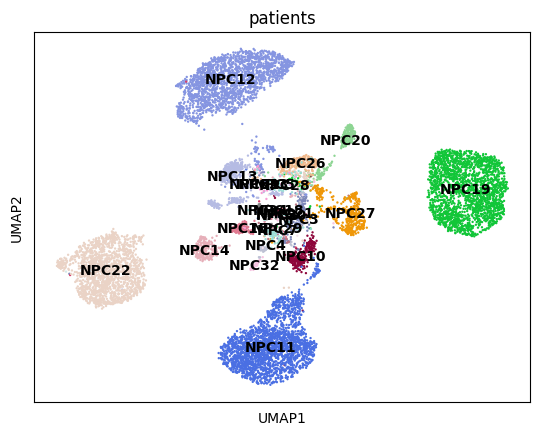

In [30]:
# 看看新增了哪些分数列
print([c for c in adata.obs.columns if c.endswith("_score")])

# 画前4个 meta-program 分数
plot_cols = score_cols[:4]
sc.pl.umap(
    adata,
    color=plot_cols,
    ncols=2,
    cmap="viridis",
    save="_meta_program_scores.pdf"
)

# 画每个细胞的主导 program
sc.pl.umap(
    adata,
    color="patients",
    legend_loc="on data",
    save="patients.pdf"  
)

In [59]:
adata.obs

,nCount_RNA,nFeature_RNA,percent.mt,patients,RNA_snn_res.0.3,seurat_clusters,doublet_score,Contamination,RNA_snn_res.1,MP1_score,MP2_score,MP3_score,MP4_score,meta_program_max,meta_program_max_score
AATATGGAGTCGCACG-1_NPC2_CA,2229.0,1533,3.992822,NPC2,4,20,0.000029,0.046900,20,-0.016826,0.193044,0.504920,0.591510,MP4,0.591510
ACTCACAAGATTAGGA-1_NPC2_CA,36586.0,7354,4.550921,NPC2,4,10,0.000460,0.072487,10,0.802530,0.416591,0.766100,0.213231,MP1,0.802530
CAACCAATCAGCACTA-1_NPC2_CA,36048.0,7906,3.573014,NPC2,4,10,0.000468,0.069852,10,0.579663,0.464312,0.746603,0.307511,MP3,0.746603
CAGCACTAGTGCCCGA-1_NPC2_CA,3254.0,1625,6.177013,NPC2,4,10,0.000095,0.041944,10,0.541251,0.433620,0.523791,-0.019210,MP1,0.541251
CCGTAATGTTCCTGAG-1_NPC2_CA,2015.0,1385,1.488834,NPC2,4,8,0.000104,0.002917,8,0.240092,0.023491,-0.011446,0.378010,MP4,0.378010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGGCTCAGTCTTGGTG-1_NPC34_CA,41765.0,7194,8.756136,NPC34,4,14,0.000094,0.015294,14,0.019205,0.715018,0.436577,0.611934,MP2,0.715018
TGGTCACAGCTAGAGG-1_NPC34_CA,15056.0,4450,10.361318,NPC34,4,14,0.005538,0.048170,14,0.017919,0.583326,0.831993,0.188726,MP3,0.831993
TGGTTAGTCTGGCACG-1_NPC34_CA,3705.0,1680,14.736842,NPC34,4,14,0.000018,0.122633,14,-0.127251,0.415130,0.598889,0.536362,MP3,0.598889
TGTAAGCCAGGGCTGT-1_NPC34_CA,4865.0,2259,14.470709,NPC34,10,13,0.072232,0.174370,13,-0.050221,0.396826,0.494658,0.072092,MP3,0.494658
